## <font color='46B8A9'> **Caso de Estudio: Clustering de Países - Aprendizaje No Supervisado**

## <font color='8EC044'> **Descripción**

El desarrollo de un país es un fenómeno multifacético que involucra múltiples dimensiones, como la economía, la salud, la fertilidad, el comercio y la estabilidad macroeconómica. Variables como el ingreso per cápita, la esperanza de vida, la tasa de mortalidad infantil y el acceso a servicios de salud son esenciales para entender el nivel de bienestar de una nación y la calidad de vida de su población. A su vez, factores como la inflación, las importaciones y exportaciones influyen directamente en el crecimiento económico y en la sostenibilidad de los países.

En este caso de estudio, se trabajará con un conjunto de datos que contiene información sobre diversos indicadores económicos y sanitarios de diferentes países. Utilizando técnicas de aprendizaje no supervisado, se planea realizar un análisis para identificar agrupamientos naturales de países con características similares. El objetivo es descubrir patrones ocultos en los datos que permitan clasificar a las naciones en grupos homogéneos según su nivel de desarrollo socioeconómico y sanitario, sin utilizar etiquetas o categorías predefinidas.

## <font color='8EC044'> **Datos**

* **Country:** Nombre del país.

* **child_mort:** Muertes de niños menores de 5 años por cada 1000 nacimientos vivos.

* **exports:** Exportaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita.

* **health:** Gasto total en salud per cápita. Expresado como porcentaje del PIB per cápita.

* **imports:** Importaciones de bienes y servicios per cápita. Expresadas como porcentaje del PIB per cápita.

* **income:** Ingreso neto por persona.

* **inflation:** La medida de la tasa de crecimiento anual del PIB Total.

* **life_expec:** Número promedio de años que viviría un recién nacido si las tasas de mortalidad actuales se mantuvieran constantes.

* **total_fer:** Número de hijos que tendría cada mujer si las tasas de fertilidad por edad actuales se mantuvieran constantes.

* **gdpp:** PIB per cápita. Calculado como el PIB total dividido por la población total.

## <font color='8EC044'> **1. Inicialización**

### <font color='FF7F50'> **1.1. Librerías**

In [ ]:
!pip install kneed

# Eliminar advertencias
import warnings
warnings.filterwarnings("ignore")

# Datos
import os
from google.colab import files
import pandas as pd
import numpy as np
from itertools import product

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

# Modelado
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors

### <font color='FF7F50'> **1.2. Descarga y carga de datos desde Kaggle**

**Instrucciones:**

**1.** Crear un archivo kaggle.json con el token de autenticación (en Kaggle → hacer clic en el ícono de usuario en la esquina superior derecha → configuración → API → crear nuevo token).

**2.** Subir el archivo kaggle.json a este espacio de trabajo de Colab.

In [ ]:
# Subir el archivo kaggle.json
uploaded = files.upload()

Saving kaggle.json to kaggle.json


**3.** Configurar la autenticación con Kaggle usando el archivo kaggle.json y descargar el conjunto de datos desde el repositorio zohrehtofighizavareh/country-dataset en el directorio actual.

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle datasets download -d zohrehtofighizavareh/country-dataset

Dataset URL: https://www.kaggle.com/datasets/zohrehtofighizavareh/country-dataset
License(s): unknown
  0% 0.00/4.69k [00:00<?, ?B/s]
100% 4.69k/4.69k [00:00<00:00, 18.6MB/s]


**4.** Descomprimir e inspeccionar datos.

In [ ]:
!ls

country-dataset.zip  kaggle.json  sample_data


In [ ]:
!unzip country-dataset.zip > /dev/null

In [ ]:
!wc *.csv

 168  205 9229 Country_Dataset.csv


**5.** Cargar el dataset con pandas.

In [ ]:
df = pd.read_csv("Country_Dataset.csv")
df

,Country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


### <font color='FF7F50'> **1.3. Funciones**

In [ ]:
#Función para graficar las variables numéricas a través de Boxplot e histograma
def graficar_histograma_y_boxplot(df, columna):
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        row_heights=[0.4, 0.6],
        vertical_spacing=0.1,
        subplot_titles=(
            f'Boxplot de {columna}',
            f'Histograma de {columna}'
        )
    )

    # Boxplot (Fila 1)
    fig.add_trace(
        go.Box(
            y=df[columna],
            name=columna,
            boxpoints='outliers',
            marker_color='blue',
            fillcolor='rgba(173, 216, 230, 0.5)',
            line=dict(color='blue')
        ),
        row=1, col=1
    )

    # Histograma (Fila 2)
    fig.add_trace(
        go.Histogram(
            x=df[columna],
            nbinsx=20,
            marker_color='tomato',
            name='Frecuencia'
        ),
        row=2, col=1
    )

    # Layout y ajustes
    fig.update_layout(
        height=700,
        width=1000,
        title_text=f'Distribución de {columna}: Boxplot e histograma',
        title_x=0.5,
        showlegend=False
    )

    fig.update_xaxes(title_text=columna, row=2, col=1)
    fig.update_yaxes(title_text="Frecuencia", row=2, col=1)

    fig.show()

## <font color='8EC044'> **2. Análisis exploratorio de los datos**

### <font color='FF7F50'> **2.1. Descripción general de los datos**

In [ ]:
# Obtener el número de filas y columnas del DataFrame
rows, cols = df.shape
print(f'Hay {rows} filas y {cols} columnas en el dataset')

Hay 167 filas y 10 columnas en el dataset


In [ ]:
# Mostrar información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
# Contar cuántos países distintos hay en la columna 'Country'
df['Country'].nunique()

167

#### **2.1.1. Descripción de variables numéricas**

Mediana, moda, desviación estándar y quantiles:

In [ ]:
# Seleccionar columnas numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


### <font color='FF7F50'> **2.2. Datos faltantes**

In [ ]:
# Contar la cantidad de valores nulos en cada columna del DataFrame
df.isna().sum()

,0
Country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
# Imprimir el número de datos nulos en el dataset
print(f'Los datos nulos en el DataFrame son {df.isnull().sum().sum()}')

Los datos nulos en el DataFrame son 0


### <font color='FF7F50'> **2.3. Datos duplicados**

In [ ]:
# Imprimir el número de datos duplicados en el dataset
print('Los datos duplicados en el DataFrame son', df.duplicated().sum())

Los datos duplicados en el DataFrame son 0


### <font color='FF7F50'> **2.4. Análisis univariado**

***child_mort:***

In [ ]:
graficar_histograma_y_boxplot(df, 'child_mort')

La variable child_mort representa una tasa de mortalidad infantil baja para la mayoría de los países; sin embargo, a través del boxplot es posible identificar que existen países con tasas extremadamente altas, los cuales deben ser estudiados individualmente para determinar si se trata de datos atípicos o de países con graves problemas sociales, como deficiencias en salud pública o pobreza extrema.

***exports:***

In [ ]:
graficar_histograma_y_boxplot(df, 'exports')

A través del histograma se observa un sesgo hacia la derecha, y es posible determinar que la gran mayoría de los países exportan entre el 20% y el 70% de su PIB per cápita. Además, el boxplot muestra determinados valores atípicos bastante elevados, que representan países que exportan por encima del 100%.

***health:***

In [ ]:
graficar_histograma_y_boxplot(df, 'health')

Se observa una distribución ligeramente sesgada hacia la derecha, donde la mayoría de los países destina entre el 4% y el 8% de su PIB per cápita a la salud. Hay pocos países con un gasto en salud mayor al 10% de su PIB per cápita, aunque se presenta un pequeño pico de países que destinan cerca del 12%. En general, son pocos los países que gastan menos del 2% o más del 13% de su PIB per cápita en salud, siendo estos últimos considerados valores atípicos.

***imports:***

In [ ]:
graficar_histograma_y_boxplot(df, 'imports')

Tras analizar ambos gráficos correspondientes a la variable imports, se observa una clara concentración en niveles moderados, ya que la mayoría de los países presentan importaciones per cápita entre el 20% y el 60% de su PIB per cápita. El histograma muestra una distribución con sesgo hacia la derecha, lo que indica la presencia de países con valores significativamente altos. Esta asimetría se confirma en el boxplot, donde se identifican varios valores atípicos por encima del 100%, e incluso algunos que superan el 150%.

***income:***

In [ ]:
graficar_histograma_y_boxplot(df, 'income')

El análisis del boxplot y el histograma de la variable income muestra una distribución desigual del ingreso neto por persona a nivel global. La mayoría de los países se concentran en niveles bajos (menores a 20.000 dólares), lo que indica una fuerte asimetría hacia la derecha. Esto se refuerza con la presencia de múltiples valores atípicos que superan los 100.000 dólares, representando economías con ingresos muy elevados en comparación con el resto.

***inflation:***

In [ ]:
graficar_histograma_y_boxplot(df, 'inflation')

El análisis conjunto del histograma y el boxplot de la variable inflation (tasa de crecimiento anual del PIB total) revela una fuerte concentración de países con tasas de inflación moderadas, principalmente entre el 0% y el 20%. La distribución presenta un sesgo positivo, es decir, hacia la derecha, con algunos valores atípicos que superan el 40%, e incluso llegan a superar el 100%.

***life_expec:***

In [ ]:
graficar_histograma_y_boxplot(df, 'life_expec')

La distribución muestra una mediana cercana a los 73 años, con la mayoría de los países entre los 65 y 80 años, lo que indica una esperanza de vida relativamente alta a nivel global. Sin embargo, hay algunos países con valores muy bajos, incluso menores a los 50 años, lo cual evidencia la presencia de outliers.

***total_fer:***

In [ ]:
graficar_histograma_y_boxplot(df, 'total_fer')

El análisis de las gráficas de la variable total_fer muestra una mediana cercana a 2,5 hijos en promedio por mujer, y el histograma indica una concentración significativa de países con tasas de fertilidad bajas (entre 1 y 3 hijos). Sin embargo, se observan datos atípicos, ya que existen valores extremos de hasta 7 hijos.

***gdpp:***

In [ ]:
graficar_histograma_y_boxplot(df, 'gdpp')

Una vez analizados los gráficos, se observa que el boxplot sugiere posibles valores atípicos en el extremo superior (países con un PIB per cápita muy alto), mientras que el histograma refleja una asimetría positiva, lo que indica que la mayoría de los países tienen un PIB per cápita menor a 20.000 USD.

### <font color='FF7F50'> **2.5. Matriz de correlación**

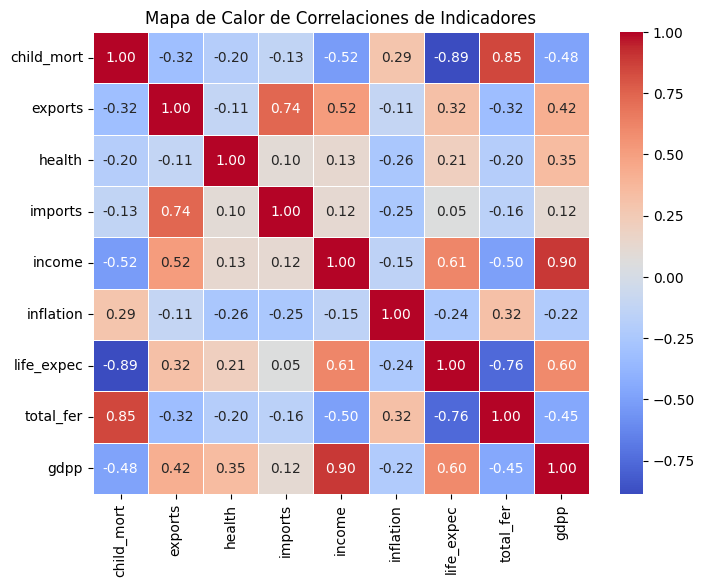

In [ ]:
# Se calcula la matriz de correlación entre las variables numéricas
correlation_matrix = df.iloc[:, 1:].corr()  # Se elimina la primera variable que representa los países
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlaciones de Indicadores')
plt.show()

Entre los principales hallazgos obtenidos a partir del análisis de la matriz de correlación, se destacan las siguientes relaciones significativas:

La mortalidad infantil (child_mort) muestra una estrecha asociación con variables económicas, sanitarias y demográficas. En primer lugar, presenta una fuerte correlación negativa con el ingreso neto per cápita y el PIB per cápita, lo que indica que, a mayores niveles de desarrollo económico, menor es la probabilidad de muerte en menores de cinco años. En segundo lugar, se observa una relación negativa con la esperanza de vida, lo que sugiere que, en contextos donde las personas viven más tiempo, también existen mejores condiciones para la supervivencia infantil. Finalmente, existe una correlación positiva con la tasa de fertilidad: a mayor número de hijos por mujer, mayor es la mortalidad infantil.

En cuanto a la apertura comercial, se evidencia una alta correlación positiva entre exportaciones e importaciones, lo cual es coherente con economías abiertas que participan activamente en el comercio internacional. Además, tanto las exportaciones como las importaciones presentan correlaciones moderadas con el PIB per cápita y el ingreso neto, lo que sugiere que los países con mayor capacidad económica tienden a integrarse más en los mercados globales.

Respecto al gasto en salud (health), aunque muestra una correlación positiva con el PIB per cápita, esta no es particularmente fuerte. De forma interesante, su correlación con la mortalidad infantil es baja (-0,20), lo cual es contrario a lo que podría esperarse.

Finalmente, las altas tasas de fertilidad se asocian de manera clara con una menor esperanza de vida y, curiosamente, con un menor ingreso neto por persona.

## <font color='8EC044'> **3. Preprocesamiento de los datos**

### <font color='FF7F50'> **3.1. Tratamiento de datos atípicos con winsorización**

Para el tratamiento de valores atípicos en las variables numéricas, se opta por utilizar la técnica de winsorización, la cual permite reducir el impacto de los valores extremos sin eliminarlos ni alterar significativamente la distribución de los datos.

En todas las variables, excepto life_expec, los outliers se presentan en el extremo superior. Por ello, se limita cada variable al rango comprendido entre su valor mínimo y el percentil 95, lo que recorta los valores atípicos altos manteniendo el resto de la información.

En el caso de life_expec, los outliers se encuentran en el extremo inferior, por lo que se aplica la winsorización utilizando el percentil 5 como límite inferior y el valor máximo como límite superior, ajustando el método a su comportamiento específico.

Esta estrategia permite tratar los valores atípicos de manera coherente, minimizando su influencia sin perder observaciones valiosas.

In [ ]:
# Tratamiento de valores atípicos mayores
numeric_cols = ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'total_fer', 'gdpp']
data_to_winsorize = df[numeric_cols].copy()

print("Valores descriptivos ANTES de Winsorización (ej. para 'child_mort'):")
display(data_to_winsorize['child_mort'].describe().T)

# Aplicar Winsorización a cada columna numérica
# Usaremos el valor mínimo y el percentil 95
for col in data_to_winsorize.columns:
    lower_percentile = data_to_winsorize[col].min()
    upper_percentile = data_to_winsorize[col].quantile(0.95)

    # 'clip' limita los valores a los percentiles definidos
    data_to_winsorize[col] = data_to_winsorize[col].clip(lower=lower_percentile, upper=upper_percentile)

print("\nValores descriptivos DESPUÉS de Winsorización (ej. para 'child_mort'):")
display(data_to_winsorize['child_mort'].describe().T)

Valores descriptivos ANTES de Winsorización (ej. para 'child_mort'):


,child_mort
count,167.000000
mean,38.270060
std,40.328931
min,2.600000
25%,8.250000
50%,19.300000
75%,62.100000
max,208.000000



Valores descriptivos DESPUÉS de Winsorización (ej. para 'child_mort'):


,child_mort
count,167.000000
mean,36.785030
std,36.215872
min,2.600000
25%,8.250000
50%,19.300000
75%,62.100000
max,116.000000


In [ ]:
# Tratamiento de valores atípicos menores
numeric_cols1 = ['life_expec']
data_to_winsorize1 = df[numeric_cols1].copy()

print("Valores descriptivos ANTES de Winsorización (ej. para 'life_expec'):")
display(data_to_winsorize1['life_expec'].describe().T)

# Aplicar Winsorización a cada columna numérica
# Usaremos el valor máximo y el percentil 05
for col in data_to_winsorize1.columns:
    lower_percentile1 = data_to_winsorize1[col].quantile(0.05)
    upper_percentile1 = data_to_winsorize1[col].max()

    # 'clip' limita los valores a los percentiles definidos
    data_to_winsorize1[col] = data_to_winsorize1[col].clip(lower=lower_percentile1, upper=upper_percentile1)

print("\nValores descriptivos DESPUÉS de Winsorización (ej. para 'life_expec'):")
display(data_to_winsorize1['life_expec'].describe().T)

Valores descriptivos ANTES de Winsorización (ej. para 'life_expec'):


,life_expec
count,167.000000
mean,70.555689
std,8.893172
min,32.100000
25%,65.300000
50%,73.100000
75%,76.800000
max,82.800000



Valores descriptivos DESPUÉS de Winsorización (ej. para 'life_expec'):


,life_expec
count,167.000000
mean,70.863593
std,8.085376
min,55.780000
25%,65.300000
50%,73.100000
75%,76.800000
max,82.800000


In [ ]:
# Atípicos menores (life_expec)
original_life = df['life_expec']
winsorized_life = data_to_winsorize1['life_expec']
modified_life = (original_life != winsorized_life).sum()
print(f"'life_expec': {modified_life} valores winsorizados (atípicos menores)")

# Atípicos mayores (otras columnas)
for col in numeric_cols:
    original = df[col]
    winsorized = data_to_winsorize[col]
    modified = (original != winsorized).sum()
    print(f"'{col}': {modified} valores winsorizados (atípicos mayores)")

'life_expec': 9 valores winsorizados (atípicos menores)
'child_mort': 8 valores winsorizados (atípicos mayores)
'exports': 9 valores winsorizados (atípicos mayores)
'health': 9 valores winsorizados (atípicos mayores)
'imports': 9 valores winsorizados (atípicos mayores)
'income': 9 valores winsorizados (atípicos mayores)
'inflation': 9 valores winsorizados (atípicos mayores)
'total_fer': 9 valores winsorizados (atípicos mayores)
'gdpp': 9 valores winsorizados (atípicos mayores)


In [ ]:
df_winsorized = df.copy()

# Reemplazar columnas con las versiones winsorizadas
df_winsorized['life_expec'] = data_to_winsorize1['life_expec']
for col in numeric_cols:
    df_winsorized[col] = data_to_winsorize[col]

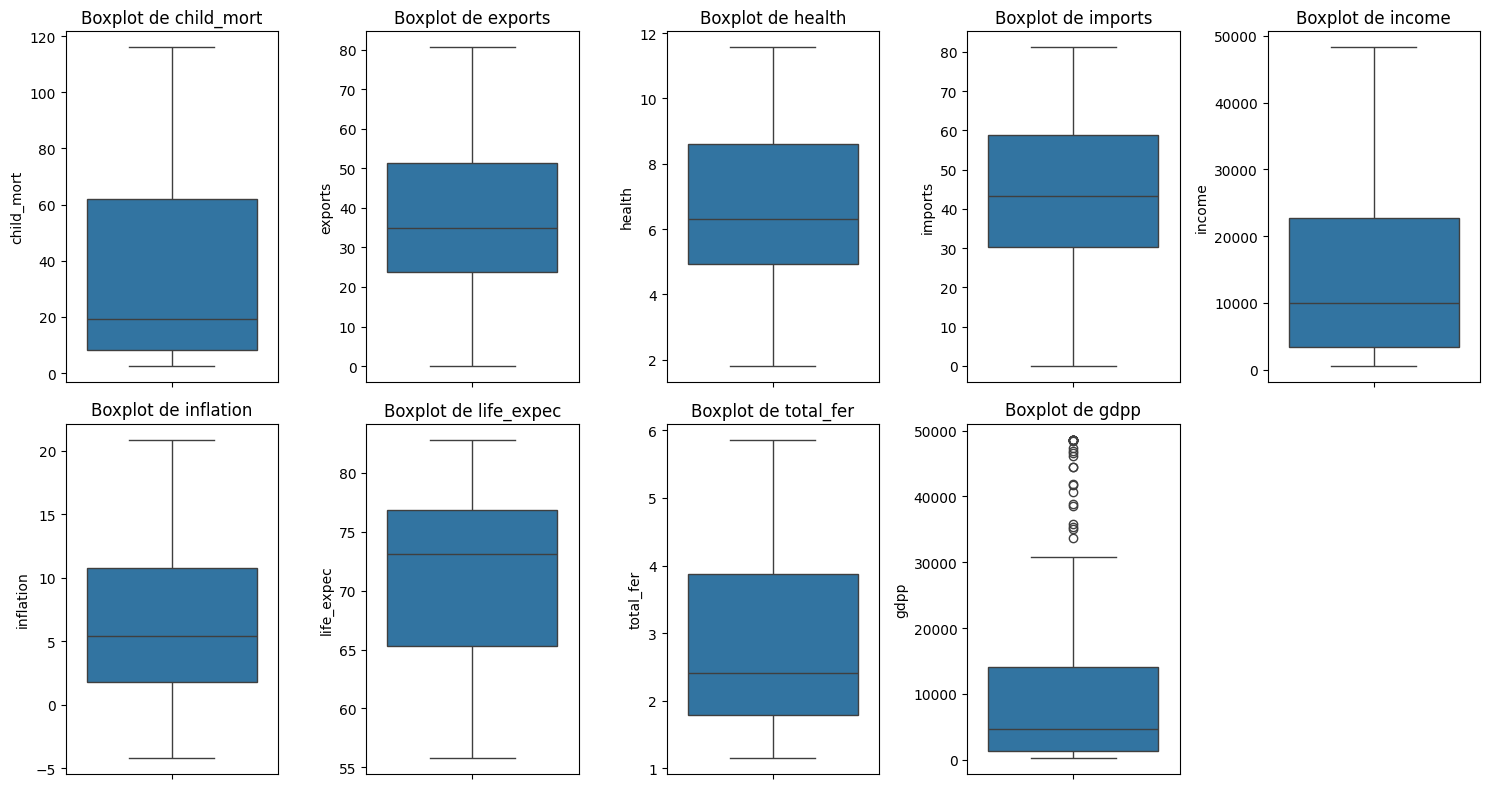

In [ ]:
# Seleccionar solo las columnas numéricas del DataFrame
numeric_cols = df_winsorized.select_dtypes(include='number').columns.tolist()

# Boxplots de variables numéricas para visualizar outliers
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i)
    sns.boxplot(y=df_winsorized[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()

plt.show()

Después de aplicar una winsorización general a las variables numéricas del dataset, observamos que la columna gdpp seguía presentando valores atípicos en los diagramas de caja (boxplots). Esto se debe a que el límite superior tradicional para detectar outliers en un boxplot (Q3 + 1.5 × IQR) es más alto que el percentil 90 utilizado inicialmente para la winsorización, por lo que algunos valores dentro de ese rango aún se consideran atípicos visualmente.

Para abordar esta situación, se ajustó el límite superior de winsorización al percentil 85, reduciendo así los valores extremos de gdpp de manera más estricta. De esta forma, se logró disminuir significativamente la presencia de valores atípicos, lo que facilita un análisis más robusto y estable.

In [ ]:
# Winsorización de 'gdpp' entre los percentiles 5 y 85 para reducir el impacto de outliers
lower_limit = df['gdpp'].quantile(0.05)
upper_limit = df['gdpp'].quantile(0.85)

df_winsorized['gdpp'] = df['gdpp'].clip(lower=lower_limit, upper=upper_limit)

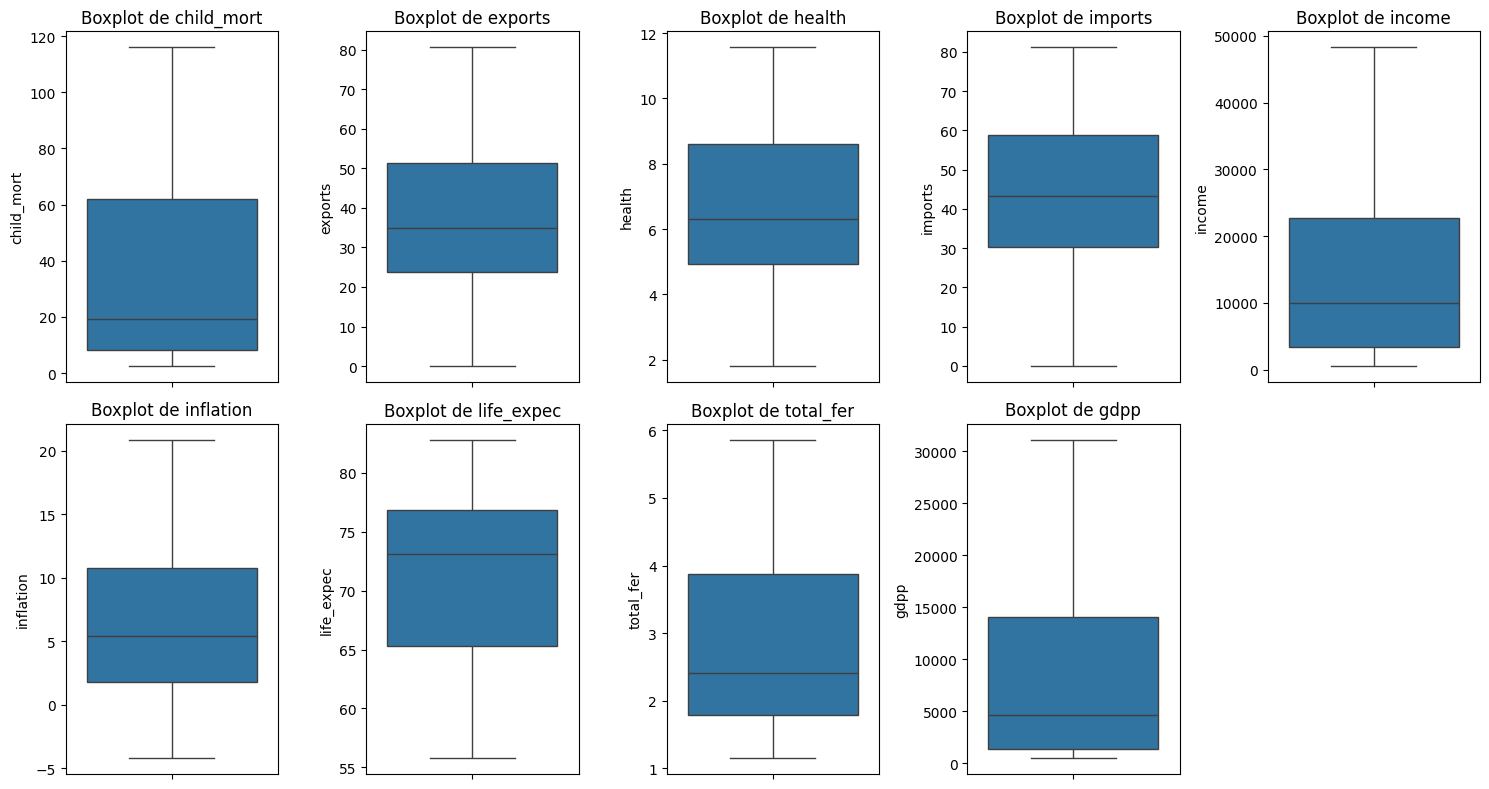

In [ ]:
# Seleccionar solo las columnas numéricas del DataFrame
numeric_cols = df_winsorized.select_dtypes(include='number').columns.tolist()

# Boxplots de variables numéricas para visualizar outliers
plt.figure(figsize=(15, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, (len(numeric_cols) + 1) // 2, i)
    sns.boxplot(y=df_winsorized[col])
    plt.title(f'Boxplot de {col}')
    plt.tight_layout()

plt.show()

Después de este ajuste, ninguna variable presentó valores atípicos visibles en los diagramas de caja, y toda la información tratada se guardó en un nuevo dataset llamado df_winsorized, el cual se utilizará para los análisis y modelamientos posteriores.

### <font color='FF7F50'> **3.2. Estandarización de variables numéricas con Z-Score**

En este caso se utiliza StandardScaler, que aplica la estandarización mediante Z-Score, para transformar las variables numéricas a una escala con media cero y desviación estándar uno. Esta transformación es necesaria porque se aplicará el algoritmo de análisis de componentes principales (PCA), el cual es sensible a la escala de los datos.

PCA identifica los componentes principales basándose en la varianza de las variables, por lo que si las variables tienen diferentes unidades y rangos, aquellas con mayor escala dominarán el análisis y sesgarán los resultados. Al utilizar StandardScaler, se asegura que todas las variables contribuyan de manera equilibrada en el cálculo de la varianza total.

Además, esta estandarización también es fundamental para los algoritmos de aprendizaje no supervisado que se implementarán posteriormente, y resulta válida para garantizar un desempeño adecuado y resultados confiables.

In [ ]:
# Seleccionar solo las columnas numéricas para escalar
numeric_cols = df_winsorized.select_dtypes(include='number').columns.tolist()

# Crear copia del DataFrame para no modificar el original
df_scaled = df_winsorized.copy()

# Aplicar escalado solo a las columnas numéricas
scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

In [ ]:
df_scaled

,Country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,1.479341,-1.440180,0.325979,-0.013380,-0.958349,0.394438,-1.819049,2.016421,-0.865028
1,Albania,-0.559029,-0.548655,-0.076806,0.185228,-0.394006,-0.383226,0.674398,-0.880535,-0.542889
2,Algeria,-0.262690,-0.033552,-1.007512,-0.738030,-0.192552,1.440750,0.699208,-0.019090,-0.509191
3,Angola,2.193878,1.150195,-1.523702,-0.120735,-0.667360,2.190136,-1.335246,2.044904,-0.593893
4,Antigua and Barbuda,-0.733509,0.318105,-0.280153,0.738110,0.227992,-0.862393,0.736424,-0.547072,0.195744
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,-0.210069,0.372587,-0.585175,0.405307,-0.867457,-0.677011,-0.975495,0.404685,-0.644896
163,Venezuela,-0.545182,-0.523891,-0.718133,-1.478784,0.051635,2.190136,0.562751,-0.310870,0.314144
164,Vietnam,-0.373471,1.630628,0.036600,1.881447,-0.763000,0.812335,0.277431,-0.672121,-0.796083
165,Yemen,0.540472,-0.449597,-0.612548,-0.576997,-0.763678,2.190136,-0.417261,1.217500,-0.796083


In [ ]:
# Crear un nuevo DataFrame sin la columna 'country' para aprendizaje no supervisado
df_clean = df_scaled.drop(columns=['Country'])

# Mostrar las primeras filas para confirmar
df_clean

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.479341,-1.440180,0.325979,-0.013380,-0.958349,0.394438,-1.819049,2.016421,-0.865028
1,-0.559029,-0.548655,-0.076806,0.185228,-0.394006,-0.383226,0.674398,-0.880535,-0.542889
2,-0.262690,-0.033552,-1.007512,-0.738030,-0.192552,1.440750,0.699208,-0.019090,-0.509191
3,2.193878,1.150195,-1.523702,-0.120735,-0.667360,2.190136,-1.335246,2.044904,-0.593893
4,-0.733509,0.318105,-0.280153,0.738110,0.227992,-0.862393,0.736424,-0.547072,0.195744
...,...,...,...,...,...,...,...,...,...
162,-0.210069,0.372587,-0.585175,0.405307,-0.867457,-0.677011,-0.975495,0.404685,-0.644896
163,-0.545182,-0.523891,-0.718133,-1.478784,0.051635,2.190136,0.562751,-0.310870,0.314144
164,-0.373471,1.630628,0.036600,1.881447,-0.763000,0.812335,0.277431,-0.672121,-0.796083
165,0.540472,-0.449597,-0.612548,-0.576997,-0.763678,2.190136,-0.417261,1.217500,-0.796083


### <font color='FF7F50'> **3.3. Reducción de la dimensionalidad - PCA**

El análisis de componentes principales (PCA) se utiliza para reducir la cantidad de variables en un conjunto de datos, conservando la mayor parte de la varianza. Al transformar las variables originales en componentes no correlacionadas, se eliminan redundancias, se simplifica la estructura del dataset y se mejora la eficiencia de los algoritmos de aprendizaje no supervisado, facilitando además la visualización e interpretación de los patrones subyacentes.

In [ ]:
# Calcular la varianza explicada por cada componente
pca_full = PCA(random_state=42)
pca_full.fit(df_clean)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

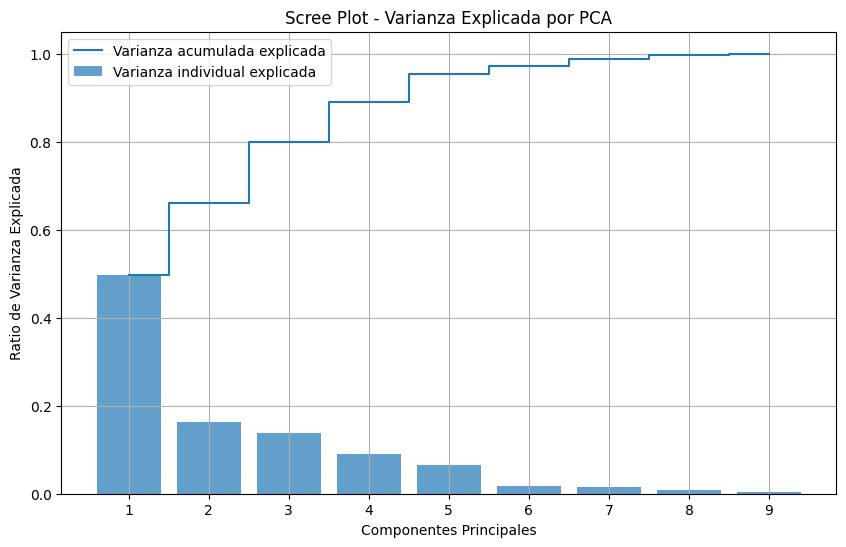

In [ ]:
# Gráfico: Muestra la varianza explicada individual y acumulada por cada componente principal
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Varianza individual explicada')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Varianza acumulada explicada')
plt.ylabel('Ratio de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Scree Plot - Varianza Explicada por PCA')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
# Varianza explicada por cada componente principal
varianza_exp = pca_full.explained_variance_ratio_
varianza_exp

array([0.49785741, 0.16367859, 0.13759619, 0.09108155, 0.06434263,
       0.0185427 , 0.01505654, 0.00870049, 0.00314389])

In [ ]:
# Varianza explicada acumulada
cumulative_explained_variance

array([0.49785741, 0.661536  , 0.79913219, 0.89021374, 0.95455637,
       0.97309907, 0.98815561, 0.99685611, 1.        ])

Como se busca reducir la dimensionalidad para facilitar la visualización de los resultados del clustering, se seleccionan las tres primeras componentes principales. Estas explican aproximadamente el 80% de la varianza total (0.799), lo cual representa un buen balance entre simplificación del conjunto de datos y preservación de la información relevante.

In [ ]:
# Aplicar PCA con 3 componentes y crear un DataFrame con los datos transformados
n_components_pca = 3
pca = PCA(n_components=n_components_pca, random_state=42)
data_pca = pca.fit_transform(df_clean)
df_pca = pd.DataFrame(data_pca, columns=[f'CP{i+1}' for i in range(n_components_pca)])

print(f"\nPrimeras filas de datos transformados por PCA ({n_components_pca} componentes):")
print(df_pca.head())
print(f"Forma de los datos transformados: {df_pca.shape}")


Primeras filas de datos transformados por PCA (3 componentes):
        CP1       CP2       CP3
0 -3.332383 -0.267545  1.075025
1  0.462378 -0.127297  0.362485
2 -0.442820 -0.657442 -1.659502
3 -3.335713  1.005985 -2.184561
4  1.307562  0.666574  0.150692
Forma de los datos transformados: (167, 3)


**Interpretación de las componentes principales:**

Se utiliza el atributo de cargas (loadings) del modelo PCA para analizar la composición de las nuevas componentes principales. Las cargas indican la relación entre cada variable original y las componentes principales. Una carga positiva alta implica que, a medida que aumenta el valor de esa variable, también lo hace el valor de la componente principal. Por el contrario, una carga negativa alta indica que un aumento en esa variable está asociado a una disminución en el valor de la componente. Estas cargas permiten interpretar el significado de cada componente, identificando qué tipo de información resumen y cómo se relacionan con las variables originales. Además, revelan la magnitud e influencia de cada variable en la formación de las componentes, facilitando una interpretación más clara de la estructura latente de los datos.

In [ ]:
# Crear un DataFrame con las cargas (loadings) de cada variable en los componentes principales del PCA
loadings_df = pd.DataFrame(pca.components_.T,
                           columns = [f'CP{i+1}' for i in range(pca.n_components_)],
                           index = df_clean.columns)

loadings_df

,CP1,CP2,CP3
child_mort,-0.419949,0.052380,0.072923
exports,0.234983,0.576353,-0.350189
health,0.173832,-0.120667,0.675755
imports,0.093135,0.751464,0.207421
income,0.407751,-0.120034,-0.187922
inflation,-0.225590,-0.137304,-0.570210
life_expec,0.429652,-0.148624,-0.084193
total_fer,-0.405113,0.026771,0.045267
gdpp,0.404556,-0.172476,-0.052823


La componente principal 1 (CP1) es la que más varianza explica, capturando alrededor del 50% de la variabilidad. Presenta cargas altas y positivas en variables como la esperanza de vida (life_expec), ingreso per cápita (income) y PIB per cápita (gdpp), mientras que tiene cargas negativas en mortalidad infantil (child_mort), tasa de fertilidad (total_fer) e inflación. Esto sugiere que CP1 representa un eje de desarrollo socioeconómico, donde valores altos indican mejores condiciones de vida y económicas.

La componente principal 2 (CP2) explica aproximadamente un 16% de la varianza y está fuertemente influenciada por las variables imports y exports. Esta componente parece capturar el grado de apertura económica o integración comercial de los países, diferenciando aquellos más vinculados al comercio internacional.

Por último, la componente principal 3 (CP3) explica un 14% adicional de la varianza. Tiene una carga positiva significativa en health (gasto en salud) y cargas negativas en inflation y exports. Esta componente refleja una combinación de inversión en salud y estabilidad macroeconómica, donde valores altos podrían asociarse con países que priorizan el bienestar social y mantienen bajo control la inflación.

## <font color='8EC044'> **4. Aplicación del algoritmo K-Means**

### <font color='FF7F50'> **4.1. Métricas de evaluación**

**Inercia:** La inercia mide la suma de las distancias cuadradas de cada punto a su centroide más cercano. Un valor bajo de inercia indica que los puntos dentro de los clústeres están más cerca unos de otros, lo que generalmente refleja una mejor cohesión interna.

**Coeficiente de silueta:** El coeficiente de silueta evalúa qué tan bien se agrupan los puntos en un clúster al comparar la distancia media de un punto a otros puntos dentro del mismo clúster con la distancia media a los puntos de otros clústeres.

**Índice de Calinski-Harabasz (Calinski score):** Este índice mide la relación entre la dispersión entre clústeres y la dispersión dentro de los clústeres. Un valor más alto sugiere que los clústeres están más compactos y bien separados, lo que indica un mejor desempeño del modelo en términos de la formación de clústeres distintivos.

### <font color='FF7F50'> **4.2. Gráfico de inercia y coeficiente de silueta**

**Método del codo:**

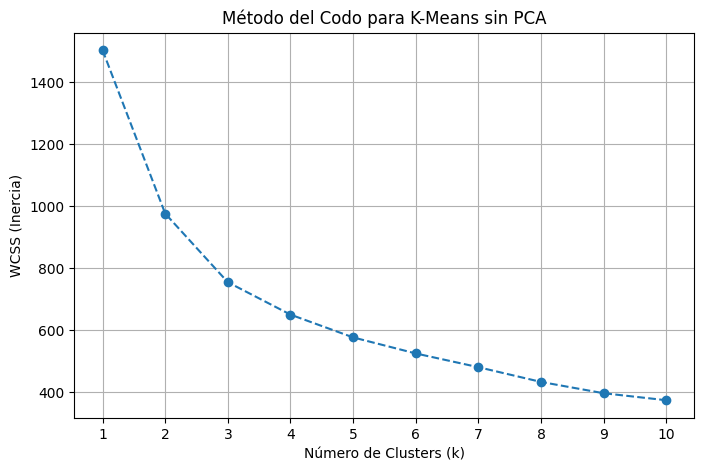

In [ ]:
# Calcular la inercia (WCSS) para diferentes valores de k y graficar el método del codo para identificar el número óptimo de clústeres
wcss = []
k_range = range(1, 11)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(df_clean)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means sin PCA')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
# Seleccion "automatica" del punto de codo
kl = KneeLocator(
    range(1,11),
    wcss,
    curve="convex",
    direction="decreasing"
)

print(kl.elbow)

3


**Coeficiente de silueta:**

Coeficiente de Silueta promedio para k=2: 0.2971
Coeficiente de Silueta promedio para k=3: 0.2778
Coeficiente de Silueta promedio para k=4: 0.2521
Coeficiente de Silueta promedio para k=5: 0.2539
Coeficiente de Silueta promedio para k=6: 0.2709
Coeficiente de Silueta promedio para k=7: 0.2509
Coeficiente de Silueta promedio para k=8: 0.2661
Coeficiente de Silueta promedio para k=9: 0.2578
Coeficiente de Silueta promedio para k=10: 0.2474


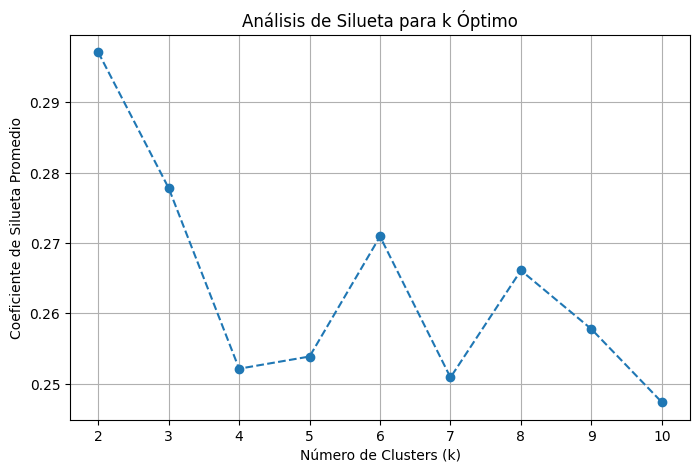

In [ ]:
# Este código evalúa el rendimiento del algoritmo K-Means para diferentes valores de k (número de clústeres) utilizando el coeficiente de silueta
silhouette_scores = []
k_range_silhouette = range(2, 11)  # Definir rango de valores de k (mínimo 2) para evaluar el coeficiente de silueta


for k in k_range_silhouette:
    kmeans_silhouette = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels_temp = kmeans_silhouette.fit_predict(df_clean)
    silhouette_avg = silhouette_score(df_clean, cluster_labels_temp)
    silhouette_scores.append(silhouette_avg)
    print(f"Coeficiente de Silueta promedio para k={k}: {silhouette_avg:.4f}")

# Graficar coeficiente de silueta promedio para cada k
plt.figure(figsize=(8,5))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Análisis de Silueta para k Óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Coeficiente de Silueta Promedio')
plt.grid(True)
plt.show()

Con base en la gráfica del método del codo, se observa que la inercia disminuye considerablemente a medida que aumenta el número de clústeres, pero la tasa de disminución se estabiliza a partir de k=3. Este punto de inflexión representa un equilibrio entre una buena cohesión interna y un número razonable de clústeres. Para confirmar esta elección, se utilizó el algoritmo KneeLocator, el cual identificó automáticamente el codo en k=3.

Adicionalmente, se analizó el coeficiente de silueta para distintos valores de k. Aunque el valor más alto se obtuvo con k=2, el coeficiente para k=3 (0.2778) se mantiene en un nivel aceptable y ofrece una mejor interpretación al segmentar los datos en más de dos grupos, sin que esto implique una pérdida significativa en la calidad del agrupamiento. Por lo tanto, se concluye que el número óptimo de clústeres para aplicar K-Means es 3, respaldado tanto por la inercia como por la evaluación del coeficiente de silueta.

### <font color='FF7F50'> **4.3. Modelo Base**

In [ ]:
k_final = 3  # Definir el número óptimo de clústeres según el análisis previo

# Ajustar y entrenar el modelo de K-means
kmeans_model_base = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
kmeans_model_base.fit(df_clean)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
# Predecir las etiquetas de clúster para los datos utilizando el modelo entrenado
cluster_labels_kmeans = kmeans_model_base.predict(df_clean)

# --- Evaluación del modelo K-Means ---
print(" ### K-MEANS ###")
print('Inertia: ', kmeans_model_base.inertia_)  # Métrica exclusiva de K-Means que indica la cohesión interna de los clústeres
print('Silhouette Score: ', silhouette_score(df_clean, kmeans_model_base.labels_))  # Evalúa la separación y cohesión de los clústeres (aplicable a cualquier algoritmo)
print('Calinski harabasz score: ', calinski_harabasz_score(df_clean, kmeans_model_base.labels_))  # Mide la relación entre dispersión inter e intra clúster (común para comparar modelos)

 ### K-MEANS ###
Inertia:  754.1626252610347
Silhouette Score:  0.2777903517342485
Calinski harabasz score:  81.42098623269952


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo K-Means base
r_base = pd.DataFrame({
    'Inertia': [kmeans_model_base.inertia_],
    'Silhouette Score': [silhouette_score(df_clean, kmeans_model_base.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_clean, kmeans_model_base.labels_)]
}, index=['Base'])

print(r_base)

         Inertia  Silhouette Score  Calinski Harabasz Score
Base  754.162625           0.27779                81.420986


### <font color='FF7F50'> **4.4. Modelo Optimizado**

Para la optimización del modelo K-Means, se seleccionó un rango de hiperparámetros que permite un balance adecuado entre exploración y eficiencia computacional. Se eligió n_clusters en el rango de 2 a 10 para cubrir un espectro razonable de posibles agrupaciones, considerando que valores menores a 2 no son válidos y que a partir de 10 clusters la interpretación puede volverse menos práctica. Para la inicialización de centroides, se incluyeron tanto el método k-means++, que es generalmente más eficiente y mejora la convergencia, como la inicialización random, para comparar y asegurar que el método óptimo sea seleccionado. En cuanto a la robustez del modelo frente a mínimos locales, se amplió el número de inicializaciones con diferentes centroides (n_init) a 10, 20 y 30, incrementando la probabilidad de obtener una solución más estable y confiable a costa de un mayor tiempo de cómputo. Finalmente, para garantizar la convergencia adecuada del algoritmo, se consideraron valores de max_iter de 100, 200 y 300 iteraciones, cubriendo desde el valor por defecto hasta configuraciones más estrictas que permiten mayor refinamiento en la búsqueda del óptimo.

In [ ]:
# Definición del espacio de hiperparámetros para optimizar K-Means
param_grid = {
    'n_clusters': range(2, 11),         # Número de clusters entre 2 y 10
    'init': ['k-means++', 'random'],    # Métodos de inicialización de centroides
    'n_init': [10, 20, 30],             # Número de inicializaciones independientes
    'max_iter': [100, 200, 300]         # Máximo de iteraciones por inicialización
}

# Variables para guardar el mejor modelo y sus métricas
best_score = -1
best_params = None
best_model = None

# Búsqueda exhaustiva sobre todas las combinaciones de hiperparámetros
for n_clusters in param_grid['n_clusters']:
    for init in param_grid['init']:
        for n_init in param_grid['n_init']:
            for max_iter in param_grid['max_iter']:
                model = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, max_iter=max_iter, random_state=42)
                labels = model.fit_predict(df_clean)
                score = silhouette_score(df_clean, labels)
                if score > best_score:
                    best_score = score
                    best_params = {'n_clusters': n_clusters, 'init': init, 'n_init': n_init, 'max_iter': max_iter}
                    best_model = model

# Mostrar los mejores hiperparámetros y el mejor puntaje obtenido
print("Mejores parámetros:", best_params)
print("Mejor Silhouette Score:", best_score)

Mejores parámetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10, 'max_iter': 100}
Mejor Silhouette Score: 0.2970773263384436


In [ ]:
# Definir el número óptimo de clusters encontrado en la optimización
k_final = 2

# Crear el modelo K-Means con los mejores parámetros encontrados
kmeans_model_opti = KMeans(n_clusters=k_final, init='k-means++', n_init=10, max_iter=100, random_state=42)

# Ajustar y entrenar el modelo de K-means opti
kmeans_model_opti.fit(df_clean)

KMeans(max_iter=100, n_clusters=2, n_init=10, random_state=42)

In [ ]:
# Predecir las etiquetas de clúster para los datos utilizando el modelo entrenado
cluster_labels_kmeans = kmeans_model_opti.predict(df_clean)

# --- Evaluación del modelo K-Means Optimizado---
print(" ### K-MEANS OPTIMIZADO ###")
print('Inertia: ', kmeans_model_opti.inertia_)  # Métrica exclusiva de K-Means que indica la cohesión interna de los clústeres
print('Silhouette Score: ', silhouette_score(df_clean, kmeans_model_opti.labels_))  # Evalúa la separación y cohesión de los clústeres (aplicable a cualquier algoritmo)
print('Calinski harabasz score: ', calinski_harabasz_score(df_clean, kmeans_model_opti.labels_))  # Mide la relación entre dispersión inter e intra clúster (común para comparar modelos)

 ### K-MEANS OPTIMIZADO ###
Inertia:  975.7350842780788
Silhouette Score:  0.2970773263384436
Calinski harabasz score:  89.16222496855801


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo K-Means opti
r_opti = pd.DataFrame({
    'Inertia': [kmeans_model_opti.inertia_],
    'Silhouette Score': [silhouette_score(df_clean, kmeans_model_opti.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_clean, kmeans_model_opti.labels_)]
}, index=['Opti'])

print(r_opti)

         Inertia  Silhouette Score  Calinski Harabasz Score
Opti  975.735084          0.297077                89.162225


### <font color='FF7F50'> **4.5. Modelo PCA**

Para el modelo basado en PCA, se decidió utilizar los hiperparámetros óptimos previamente determinados durante la optimización del modelo K-Means original. Esta elección se basa en el hecho de que dichos hiperparámetros proporcionaron el mejor rendimiento según la métrica de Silhouette Score. Aplicarlos al modelo PCA permite mantener la coherencia en la comparación de resultados, asegurando que cualquier variación en el desempeño sea atribuible únicamente a la transformación de los datos mediante PCA, y no a cambios en la configuración del modelo. Además, el aumento observado en la métrica Calinski-Harabasz en el modelo optimizado refuerza la mejora en la calidad del agrupamiento, ya que esta métrica premia clústeres más compactos y mejor separados, lo cual es una señal positiva en términos de desempeño del modelo.

In [ ]:
# Definir el número óptimo de clusters encontrado en la optimización
k_final = 2

# Crear el modelo K-Means con los mejores parámetros encontrados
kmeans_model_pca = KMeans(n_clusters=k_final, init='k-means++', n_init=10, max_iter=100, random_state=42)

# Ajustar y entrenar el modelo de K-means con PCA
kmeans_model_pca.fit(df_pca)  # Usar el df_pca

KMeans(max_iter=100, n_clusters=2, n_init=10, random_state=42)

In [ ]:
# Predecir las etiquetas de clúster para los datos utilizando el modelo entrenado
cluster_labels_kmeans = kmeans_model_pca.predict(df_pca)

# --- Evaluación del modelo K-Means PCA---
print(" ### K-MEANS con PCA ###")
print('Inertia: ', kmeans_model_pca.inertia_)  # Métrica exclusiva de K-Means que indica la cohesión interna de los clústeres
print('Silhouette Score: ', silhouette_score(df_pca, kmeans_model_pca.labels_))  # Evalúa la separación y cohesión de los clústeres (aplicable a cualquier algoritmo)
print('Calinski harabasz score: ', calinski_harabasz_score(df_pca, kmeans_model_pca.labels_))  # Mide la relación entre dispersión inter e intra clúster (común para comparar modelos)

 ### K-MEANS con PCA ###
Inertia:  676.3874251355443
Silhouette Score:  0.353333732476732
Calinski harabasz score:  127.99892412472929


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo K-Means con PCA
r_pca = pd.DataFrame({
    'Inertia': [kmeans_model_pca.inertia_],
    'Silhouette Score': [silhouette_score(df_pca, kmeans_model_pca.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_pca, kmeans_model_pca.labels_)]
}, index=['PCA'])

print(r_pca)

        Inertia  Silhouette Score  Calinski Harabasz Score
PCA  676.387425          0.353334               127.998924


### <font color='FF7F50'> **4.6. Resultados**

In [ ]:
# Combinar los resultados de evaluación de los tres modelos para facilitar la comparación
resultados_final_km = pd.concat([r_base, r_opti, r_pca], axis=0)
resultados_final_km

,Inertia,Silhouette Score,Calinski Harabasz Score
Base,754.162625,0.277790,81.420986
Opti,975.735084,0.297077,89.162225
PCA,676.387425,0.353334,127.998924


Con base en las métricas de evaluación obtenidas para los tres modelos aplicados con el algoritmo de K-Means (el modelo base, el modelo optimizado y el modelo con PCA), se pueden establecer las siguientes conclusiones comparativas:

* **Inercia:** Esta métrica mide la cohesión interna de los clústeres (menor valor es mejor). El modelo con PCA obtuvo la menor inercia (676.39), lo que indica una mayor compacidad de los clústeres formados, en comparación con el modelo base (754.16) y el modelo optimizado (975.73).

* **Silhouette Score:** Evalúa qué tan bien separados y compactos están los clústeres (mayor valor es mejor). El modelo con PCA también presentó el mayor Silhouette Score (0.3533), superando tanto al modelo base (0.2778) como al optimizado (0.2971). Esto sugiere una estructura de clústeres más clara y definida.

* **Calinski-Harabasz Score:** Mide la relación entre la dispersión entre clústeres y la dispersión dentro de ellos (mayor valor es mejor). El modelo con PCA obtuvo el valor más alto (127.99), indicando una mejor separación entre los clústeres en comparación con el modelo optimizado (89.16) y el base (81.42).

**Conclusión:** De acuerdo con todas las métricas evaluadas, el modelo basado en PCA demostró el mejor desempeño general. La aplicación de PCA no solo mejoró la calidad del agrupamiento en términos de cohesión y separación, sino que también reveló una estructura de clústeres más clara.

A partir de este modelo, se procede a identificar y listar los países que conforman cada clúster, lo que permitirá analizar las características compartidas dentro de cada grupo y extraer conclusiones relevantes sobre sus condiciones socioeconómicas y de salud.

In [ ]:
# Añadir las etiquetas de cluster a los datos PCA y a los originales (escalados) para interpretación
df_pca_results = df_pca.copy()
X_result = df.copy()

df_pca_results['Cluster_KMeans'] = cluster_labels_kmeans
X_result['Cluster_KMeans'] = cluster_labels_kmeans # Útil para perfilar clusters con variables originales

print(f"\nPrimeras filas de datos PCA con etiquetas de cluster (k={k_final}):")
display(df_pca_results.head())


Primeras filas de datos PCA con etiquetas de cluster (k=2):


,CP1,CP2,CP3,Cluster_KMeans
0,-3.332383,-0.267545,1.075025,1
1,0.462378,-0.127297,0.362485,0
2,-0.442820,-0.657442,-1.659502,1
3,-3.335713,1.005985,-2.184561,1
4,1.307562,0.666574,0.150692,0


In [ ]:
print(f"\nPrimeras filas de datos originales con etiquetas de cluster (k={k_final}):")
display(X_result.head())


Primeras filas de datos originales con etiquetas de cluster (k=2):


,Country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_KMeans
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [ ]:
# Cluster 0
print("Países en el cluster 0:")
print(X_result[X_result['Cluster_KMeans'] == 0]['Country'].values)

# Cluster 1
print("\nPaíses en el cluster 1:")
print(X_result[X_result['Cluster_KMeans'] == 1]['Country'].values)

Países en el cluster 0:
['Albania' 'Antigua and Barbuda' 'Argentina' 'Australia' 'Austria'
 'Bahamas' 'Bahrain' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Bosnia and Herzegovina' 'Brazil' 'Brunei' 'Bulgaria' 'Canada' 'Chile'
 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Denmark' 'Ecuador' 'El Salvador' 'Estonia' 'Finland' 'France' 'Georgia'
 'Germany' 'Greece' 'Grenada' 'Hungary' 'Iceland' 'Iran' 'Ireland'
 'Israel' 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kuwait' 'Latvia' 'Lebanon'
 'Libya' 'Lithuania' 'Luxembourg' 'Macedonia, FYR' 'Malaysia' 'Maldives'
 'Malta' 'Mauritius' 'Moldova' 'Montenegro' 'Netherlands' 'New Zealand'
 'Norway' 'Oman' 'Panama' 'Paraguay' 'Peru' 'Poland' 'Portugal' 'Qatar'
 'Romania' 'Russia' 'Saudi Arabia' 'Serbia' 'Seychelles' 'Singapore'
 'Slovak Republic' 'Slovenia' 'South Korea' 'Spain'
 'St. Vincent and the Grenadines' 'Suriname' 'Sweden' 'Switzerland'
 'Thailand' 'Tunisia' 'Turkey' 'Ukraine' 'United Arab Emirates'
 'United Kingdom' 'Unit

**Cluster 0:** Incluye países como: Alemania, Francia, Japón, Canadá, Australia, Reino Unido, Estados Unidos, etc. Estos países generalmente presentan:

* Baja mortalidad infantil
* Altos niveles de ingreso per cápita y PIB
* Esperanza de vida elevada
* Bajo nivel de fertilidad
* Mejores indicadores en salud, infraestructura y desarrollo económico

Este clúster representa a las naciones con alto desarrollo socioeconómico, buena calidad de vida y sistemas de salud estables.

**Cluster 1:** Incluye países como: Afganistán, Nigeria, Haití, India, Bangladesh, Congo, Chad, etc. Características comunes:

* Alta mortalidad infantil
* Bajo ingreso per cápita y PIB
* Esperanza de vida más baja
* Mayor tasa de fertilidad
* Sistemas de salud y condiciones económicas más frágiles

Este clúster representa a los países con bajo desarrollo socioeconómico, desafíos en salud pública, educación e infraestructura básica.

**Conclusión:** Los clústeres generados permiten identificar dos grandes grupos de países según su situación socioeconómica y de salud. Esta agrupación puede ser útil para priorizar estrategias de desarrollo, identificar necesidades comunes, y aplicar políticas diferenciadas según el nivel de desarrollo del grupo. Además, valida que el modelo K-Means con PCA logró capturar diferencias estructurales relevantes en los datos.

In [ ]:
# Visualización 3D de Clústeres usando el modelo basado en PCA
cluster_labels_str = pd.Series(cluster_labels_kmeans).astype(str)

fig = px.scatter_3d(data_frame=df_pca_results,
                    x='CP1',
                    y='CP2',
                    z='CP3',
                    color=cluster_labels_str,  # Usa las etiquetas para colorear los puntos
                    title='Clusters en el Espacio de 3 Componentes Principales',
                    labels={'CP1': 'Componente Principal 1',
                            'CP2': 'Componente Principal 2',
                            'CP3': 'Componente Principal 3',
                            'color': 'Cluster'}, # Etiqueta para la leyenda de colores
                    opacity=0.7, # Transparencia de los puntos
                    size_max=10) # Tamaño máximo de los puntos (si usaras 'size')

# Mejorar la apariencia (opcional)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40), # Ajustar márgenes
                  scene = dict(
                      xaxis_title='CP1',
                      yaxis_title='CP2',
                      zaxis_title='CP3'
                  ))

fig.show()

La visualización 3D de los clústeres en el espacio generado por las componentes principales (CP1, CP2 y CP3) permite evaluar de forma visual la calidad del modelo K-Means con PCA. A simple vista, se observan dos grupos diferenciados que ocupan regiones distintas del espacio tridimensional, lo cual indica que el modelo logró identificar patrones estructurales relevantes en los datos originales tras la reducción dimensional. Aunque existe un cierto grado de solapamiento entre los clústeres, particularmente en la zona intermedia, alrededor de CP1 = 0, la separación general entre los grupos es clara, especialmente a lo largo del eje CP1, siendo este el componente con mayor capacidad discriminativa.

En cuanto al balance, ambos clústeres presentan una distribución similar en términos de número de observaciones. Esta uniformidad es deseable, ya que evita la creación de clústeres desproporcionados, lo cual podría distorsionar la interpretación de los resultados. Además, la forma y disposición interna de cada clúster sugiere una estructura compacta y convexa, lo cual es consistente con las suposiciones del algoritmo K-Means. No se evidencian outliers marcados ni grupos internos dispersos, lo que refuerza la calidad del agrupamiento.

El uso de PCA se justifica ampliamente en este contexto, ya que permitió reducir la dimensionalidad de los datos sin perder información esencial para el proceso de agrupamiento. Esta transformación facilitó la visualización tridimensional y contribuyó a una segmentación más clara que la obtenida sin aplicar PCA. En resumen, el modelo K-Means optimizado sobre el espacio PCA no solo ofreció mejores métricas de evaluación, sino que también logró una segmentación visualmente coherente, lo que respalda su elección como el modelo más adecuado para representar la estructura latente de los datos.

## <font color='8EC044'> **5. Aplicación del algoritmo Hierarchical Clustering**

### <font color='FF7F50'> **5.1. Modelo Base**

In [ ]:
df_clean.shape

(167, 9)

In [ ]:
df_clean.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.479341,-1.440180,0.325979,-0.013380,-0.958349,0.394438,-1.819049,2.016421,-0.865028
1,-0.559029,-0.548655,-0.076806,0.185228,-0.394006,-0.383226,0.674398,-0.880535,-0.542889
2,-0.262690,-0.033552,-1.007512,-0.738030,-0.192552,1.440750,0.699208,-0.019090,-0.509191
3,2.193878,1.150195,-1.523702,-0.120735,-0.667360,2.190136,-1.335246,2.044904,-0.593893
4,-0.733509,0.318105,-0.280153,0.738110,0.227992,-0.862393,0.736424,-0.547072,0.195744


**Uso del dendrograma para determinar el número óptimo de clusters:**

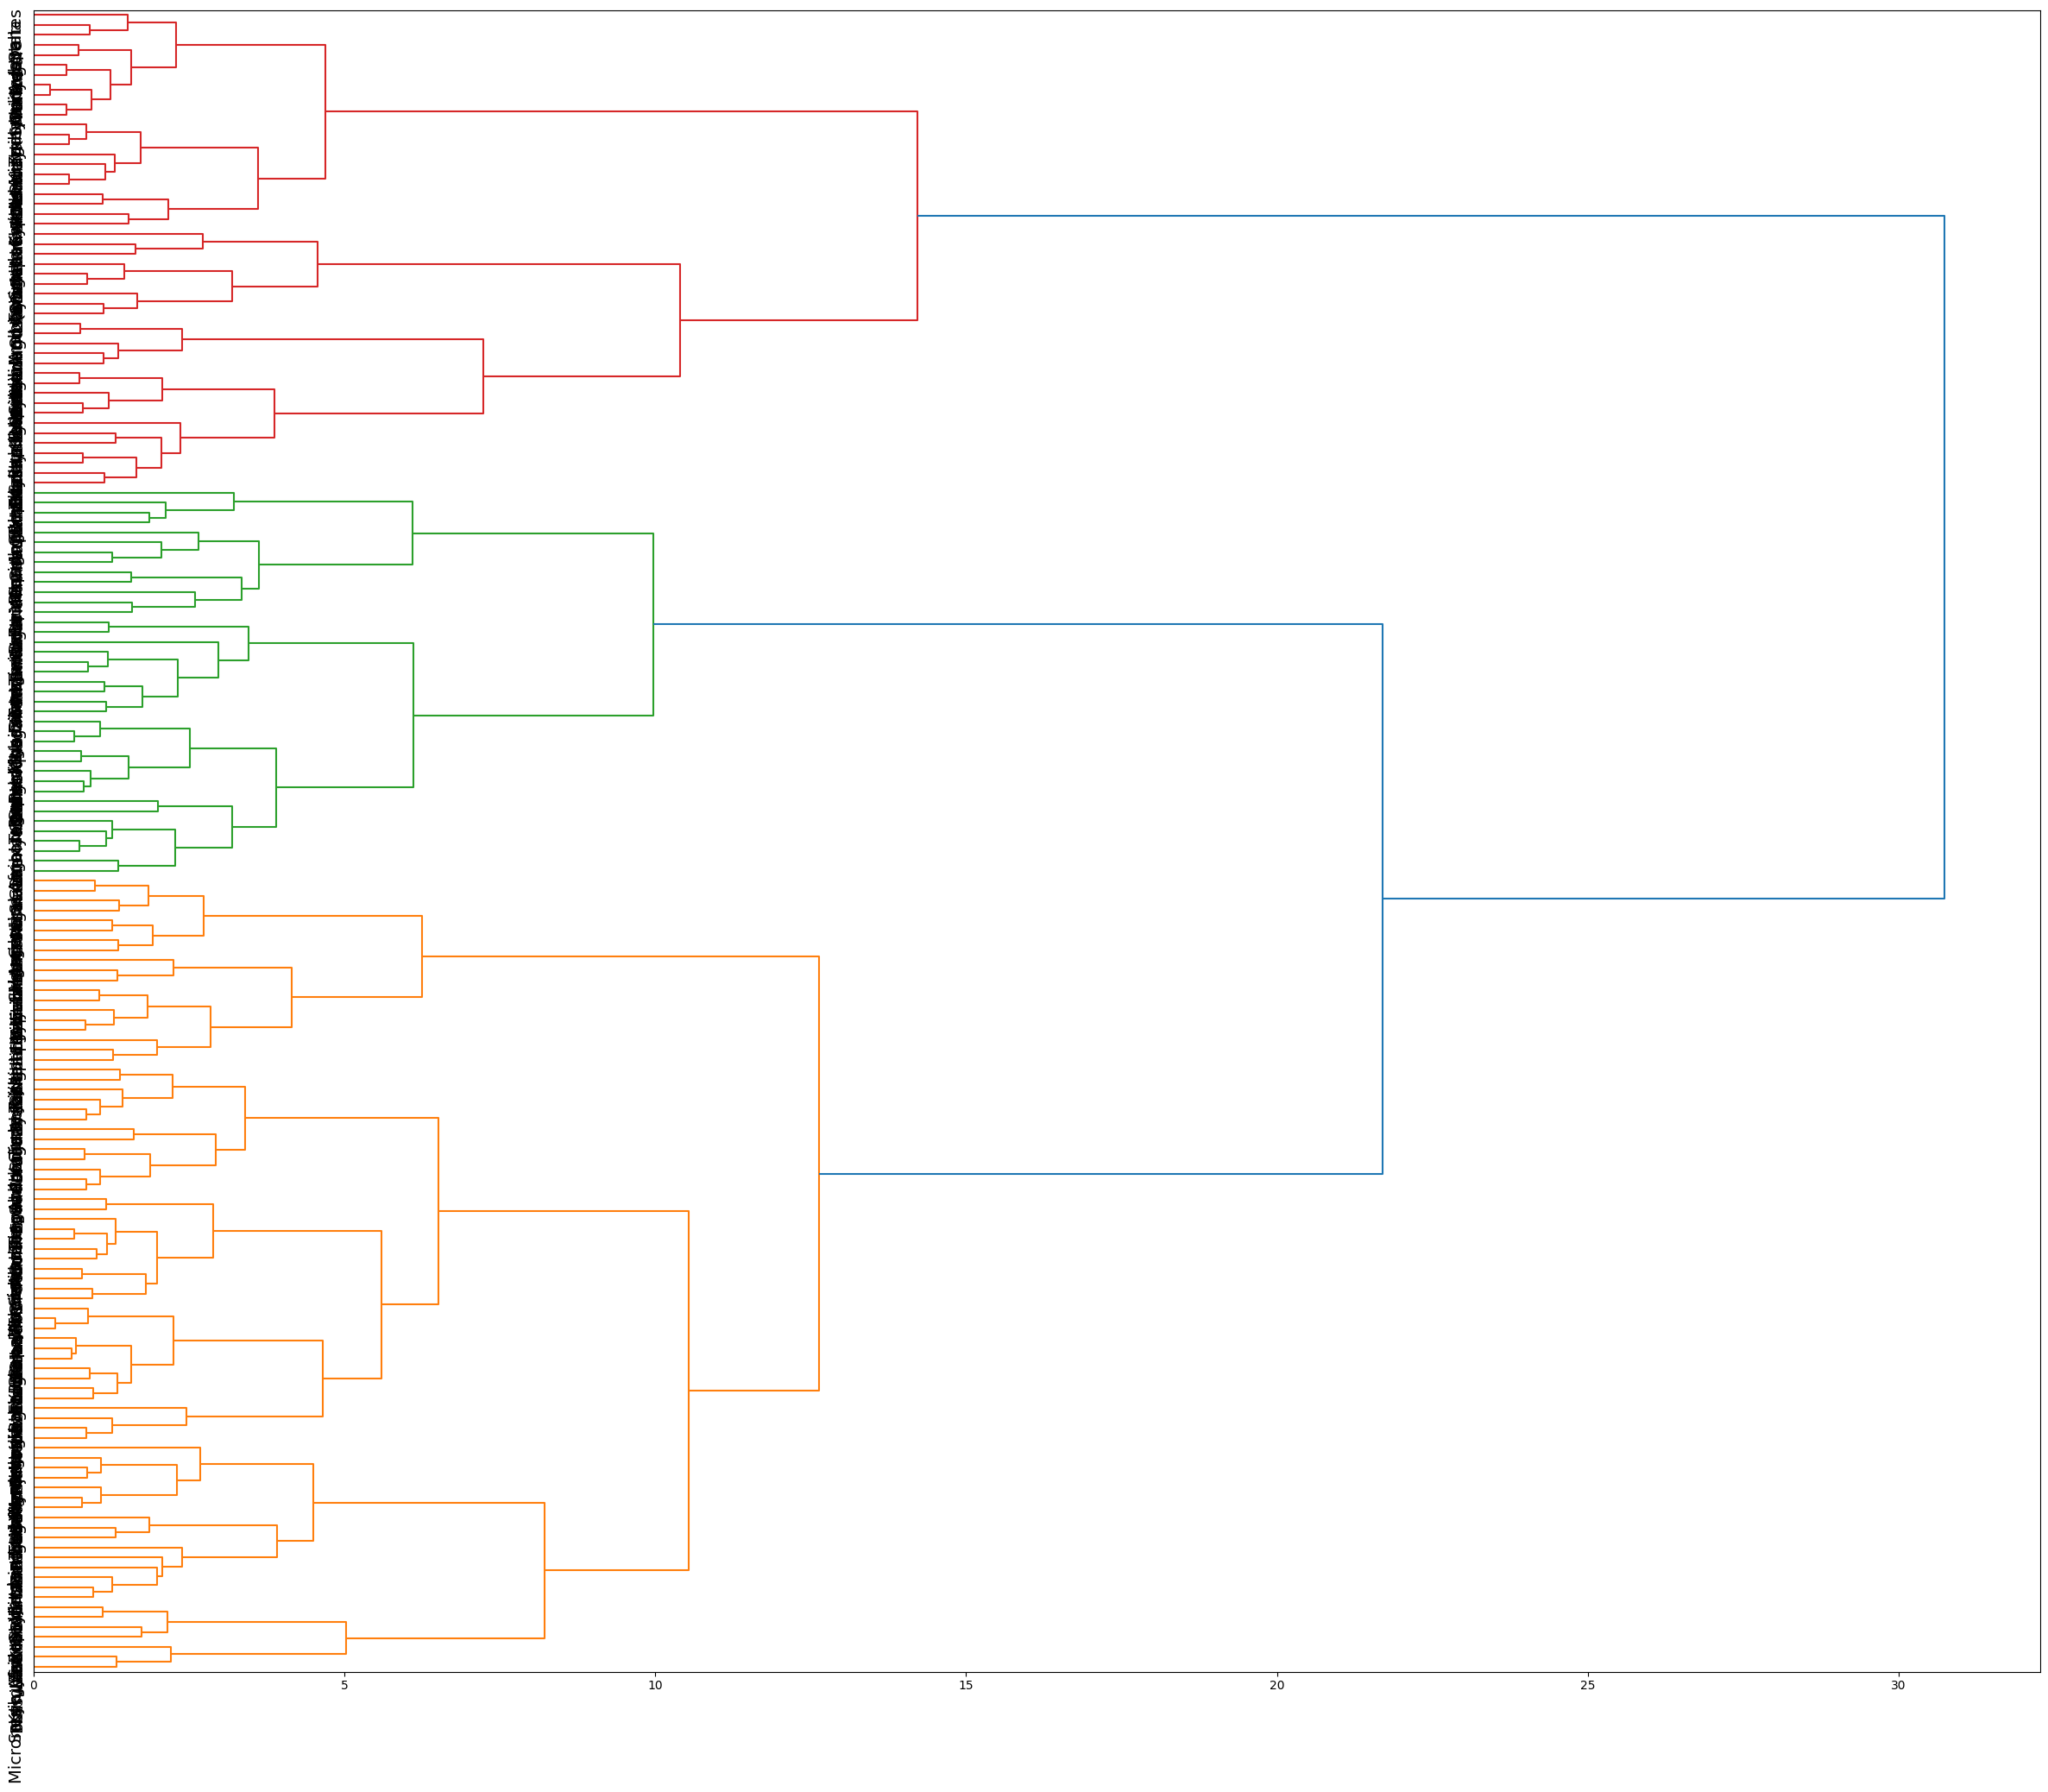

In [ ]:
%matplotlib inline

# Funcion de vinculación para agrupar los datos según similitud

Z = linkage(df_clean, 'ward')

# Gráfica del dendrograma
label_list = list(df['Country'])

plt.figure(figsize=(30, 25))
dendrogram(
    Z,
    labels=label_list,
    leaf_rotation=90,
    distance_sort = 'descending',
    orientation='right',
    show_leaf_counts=False,
    leaf_font_size=14)
plt.show()

A partir del análisis visual del gráfico, se puede determinar el número óptimo de clústeres observando la altura a la que se pueden cortar las líneas verticales más largas antes de que se unan a otras ramas (es decir, buscar el mayor salto en la distancia de fusión).

En este dendrograma, el mayor salto se observa justo antes de la unión de tres grandes bloques, lo cual sugiere que el número óptimo de clústeres es 3. Si se traza una línea horizontal alrededor de una distancia de fusión entre 15 y 20 (en el eje X), esta línea cortaría aproximadamente tres ramas principales antes de que las distancias de fusión se vuelvan mucho menores y más frecuentes.

In [ ]:
'''Cuando se utiliza el método de enlace tipo Ward en el algoritmo de clustering jerárquico, es fundamental que la métrica de
distancia empleada sea la euclidiana. Esto se debe a que el método de Ward se basa en minimizar la varianza dentro de los clústeres
al unir grupos, lo cual implica realizar cálculos relacionados con la suma de cuadrados. Estas operaciones matemáticas solo son
coherentes y válidas si se utiliza la distancia euclidiana'''

# Crear el modelo de clustering jerárquico con 3 clústeres, usando distancia euclidiana y método de enlace 'ward'
hc = AgglomerativeClustering(
    n_clusters = 3,
    metric = 'euclidean',  #
    linkage = 'ward'
)

# Ajustar el modelo a los datos y obtener las etiquetas de clúster para cada muestra
y_hc = hc.fit_predict(df_clean)
print(y_hc)

[2 1 1 2 1 1 1 0 0 1 0 0 1 1 1 0 1 2 1 1 1 1 1 0 1 2 2 1 2 0 1 2 2 1 1 1 2
 2 2 1 2 1 0 0 0 1 1 1 1 2 1 0 1 0 0 2 2 1 0 2 0 1 1 2 2 1 2 0 0 1 1 1 2 0
 0 0 1 0 1 1 2 1 0 1 2 1 1 1 1 0 0 0 1 2 2 0 0 2 0 2 1 1 1 1 1 1 2 1 1 1 0
 0 2 2 0 0 1 0 1 1 1 1 0 0 1 1 2 1 0 2 1 0 2 0 0 0 1 1 0 0 1 1 2 1 0 0 1 2
 0 2 2 1 1 1 1 2 1 0 0 0 1 1 1 1 1 2 2]


In [ ]:
# --- Evaluación del Clustering Jerárquico --- #
print(" ### CLUSTERING JERARQUICO ###")
print('Silhouette Score: ', silhouette_score(df_clean, hc.labels_))
print('Calinski harabasz score: ', calinski_harabasz_score(df_clean, hc.labels_))

 ### CLUSTERING JERARQUICO ###
Silhouette Score:  0.2515681872973491
Calinski harabasz score:  73.01192273677536


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo Clustering Jerárquico base
result_base = pd.DataFrame({
    'Silhouette Score': [silhouette_score(df_clean, hc.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_clean, hc.labels_)]
}, index=['Base'])

print(result_base)

      Silhouette Score  Calinski Harabasz Score
Base          0.251568                73.011923


### <font color='FF7F50'> **5.2. Modelo Optimizado**

Para la optimización del modelo de Clustering Jerárquico, se seleccionó un conjunto de hiperparámetros que permite evaluar distintas configuraciones estructurales del algoritmo y su sensibilidad a distintas medidas de similitud. El parámetro n_clusters se evaluó en el rango de 2 a 6, ya que este intervalo permite explorar desde una agrupación mínima válida hasta un nivel de segmentación más detallado sin llegar a una sobrefragmentación difícil de interpretar. En cuanto a la métrica de distancia (metric), se consideraron tres opciones comunes: euclidean, manhattan y cosine, ya que cada una ofrece una forma distinta de medir la similitud entre observaciones, lo cual es relevante especialmente cuando no se asume una distribución uniforme de los datos. Para el método de enlace (linkage), se incluyeron ward, complete, average y single, cubriendo las principales variantes utilizadas en la literatura. Se impuso la restricción de que el método ward solo se combine con la métrica euclidean, ya que es una condición matemática necesaria para garantizar la validez del criterio de minimización de varianza interna propio de este enfoque.

In [ ]:
# Grid de hiperparámetros
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6],
    'metric': ['euclidean', 'manhattan', 'cosine'],
    'linkage': ['ward', 'complete', 'average', 'single']
}

# Variables para guardar resultados
best_score = -1
best_params = {}
best_model = None

# Iterar sobre combinaciones
for n_clusters in param_grid['n_clusters']:
    for metric in param_grid['metric']:
        for linkage in param_grid['linkage']:
            if linkage == 'ward' and metric != 'euclidean':
                continue  # ward solo funciona con euclidean

            # Crear modelo
            model = AgglomerativeClustering(n_clusters=n_clusters, metric=metric, linkage=linkage)

            # Ajustar modelo
            labels = model.fit_predict(df_clean)

            # Calcular Silhouette
            score = silhouette_score(df_clean, labels)

            # Guardar si es el mejor
            if score > best_score:
                best_score = score
                best_params = {'n_clusters': n_clusters, 'metric': metric, 'linkage': linkage}
                best_model = model

# Imprimir resultados
print("Mejores parámetros:", best_params)
print("Mejor Silhouette Score:", best_score)

Mejores parámetros: {'n_clusters': 2, 'metric': 'euclidean', 'linkage': 'average'}
Mejor Silhouette Score: 0.30489703313555583


In [ ]:
# Modelo con mejores hiperparámetros encontrados
hc_opti = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='average'
)

# Ajustar y predecir
y_hc_opti = hc_opti.fit_predict(df_clean)
print(y_hc_opti)

[0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 0
 0 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1
 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0
 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0]


In [ ]:
# --- Evaluación del Clustering Jerárquico Optimizado --- #
print(" ### CLUSTERING JERARQUICO OPTIMIZADO ###")
print('Silhouette Score: ', silhouette_score(df_clean, hc_opti.labels_))
print('Calinski harabasz score: ', calinski_harabasz_score(df_clean, hc_opti.labels_))

 ### CLUSTERING JERARQUICO OPTIMIZADO ###
Silhouette Score:  0.30489703313555583
Calinski harabasz score:  76.58453727098758


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo Clustering Jerárquico opti
result_opti = pd.DataFrame({
    'Silhouette Score': [silhouette_score(df_clean, hc_opti.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_clean, hc_opti.labels_)]
}, index=['Opti'])

print(result_opti)

      Silhouette Score  Calinski Harabasz Score
Opti          0.304897                76.584537


### <font color='FF7F50'> **5.3. Modelo PCA**

Para el modelo basado en PCA, se decidió aplicar los hiperparámetros óptimos previamente identificados durante la optimización del modelo de Clustering Jerárquico sin reducción de dimensionalidad. Esta decisión se fundamenta en que dicha combinación de parámetros fue la que arrojó el mejor desempeño según las métricas de Silhouette Score y Calinski-Harabasz. Utilizar estos mismos hiperparámetros sobre los datos transformados por PCA permite mantener la consistencia en la evaluación del modelo, asegurando que cualquier diferencia en los resultados se deba exclusivamente al efecto de la reducción de dimensionalidad y no a cambios en la configuración del algoritmo.

In [ ]:
# Modelo PCA con mejores hiperparámetros encontrados
hc_pca = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='average'
)

# Ajustar y predecir
y_hc_pca = hc_pca.fit_predict(df_pca)  # Usar el df_pca

# Ver resultados
print(y_hc_pca)

[0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1
 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 0 0 1 1 0 0
 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0]


In [ ]:
# --- Evaluación del Clustering Jerárquico con PCA --- #
print(" ### CLUSTERING JERARQUICO PCA ###")
print('Silhouette Score: ', silhouette_score(df_pca, hc_pca.labels_))
print('Calinski harabasz score: ', calinski_harabasz_score(df_pca, hc_pca.labels_))

 ### CLUSTERING JERARQUICO PCA ###
Silhouette Score:  0.33148044993471754
Calinski harabasz score:  94.25963253668921


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo Clustering Jerárquico con PCA
result_pca = pd.DataFrame({
    'Silhouette Score': [silhouette_score(df_pca, hc_pca.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_pca, hc_pca.labels_)]
}, index=['PCA'])

print(result_pca)

     Silhouette Score  Calinski Harabasz Score
PCA           0.33148                94.259633


### <font color='FF7F50'> **5.4. Resultados**

In [ ]:
# Combinar los resultados de evaluación de los tres modelos para facilitar la comparación
resultados_final_hc = pd.concat([result_base, result_opti, result_pca], axis=0)
resultados_final_hc

,Silhouette Score,Calinski Harabasz Score
Base,0.251568,73.011923
Opti,0.304897,76.584537
PCA,0.331480,94.259633


Con base en los resultados obtenidos en las métricas de evaluación para los tres modelos de Clustering Jerárquico (modelo base, modelo optimizado y modelo basado en PCA), se puede concluir lo siguiente:

* El modelo base presenta los valores más bajos en ambas métricas: un Silhouette Score de 0.2516 y un Calinski-Harabasz Score de 73.01, lo que indica una estructura de clústeres relativamente débil, con una menor separación entre grupos y menor cohesión interna.

* El modelo optimizado, tras la búsqueda de hiperparámetros adecuados, muestra una mejora significativa respecto al modelo base, alcanzando un Silhouette Score de 0.3049 y un Calinski-Harabasz Score de 76.58. Esto evidencia una mejor delimitación entre los clústeres y una mayor calidad del agrupamiento, validando el impacto positivo de ajustar adecuadamente los hiperparámetros.

* Finalmente, el modelo basado en PCA con los hiperparámetros óptimos previamente hallados demuestra ser el más efectivo de los tres. Obtiene el mayor Silhouette Score (0.3315) y el mayor Calinski-Harabasz Score (94.26), lo que indica clústeres bien definidos, compactos y claramente separados. La aplicación de PCA no solo ha reducido la dimensionalidad, sino que ha mejorado la estructura de los datos, permitiendo al algoritmo identificar agrupaciones más coherentes.

En conclusión, el modelo de Clustering Jerárquico con reducción de dimensionalidad mediante PCA es el que proporciona el mejor rendimiento, siendo el más adecuado para representar la segmentación de los países según los indicadores socioeconómicos y de salud evaluados.

A partir de este modelo, se procede a identificar y listar los países que conforman cada clúster, lo que permitirá analizar las características compartidas dentro de cada grupo y extraer las conclusiones más relevantes.

In [ ]:
# Añadir al DataFrame una nueva columna con las etiquetas de clúster obtenidas por el modelo jerárquico con PCA
df_hc = df.copy()

# Añadir al DataFrame una nueva columna con las etiquetas de clúster obtenidas por el modelo jerárquico con PCA
df_hc['Cluster_HC'] = y_hc_pca
df_hc

,Country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_HC
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,1
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


In [ ]:
# Cluster 0
print("Países en el cluster 0:")
print(df_hc[df_hc['Cluster_HC'] == 0]['Country'].values)

# Cluster 1
print("\nPaíses en el cluster 1:")
print(df_hc[df_hc['Cluster_HC'] == 1]['Country'].values)

Países en el cluster 0:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Barbados'
 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Fiji' 'Gabon' 'Gambia' 'Georgia' 'Ghana'
 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti' 'India'
 'Indonesia' 'Iran' 'Iraq' 'Jamaica' 'Jordan' 'Kazakhstan' 'Kenya'
 'Kiribati' 'Kyrgyz Republic' 'Lao' 'Latvia' 'Lebanon' 'Lesotho' 'Liberia'
 'Macedonia, FYR' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mauritius'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Montenegro' 'Morocco'
 'Mozambique' 'Myanmar' 'Namibia' 'Nepal' 'Niger' 'Nigeria

Con base en los países asignados a cada clúster, podemos concluir lo siguiente:

**Cluster 0:** Este clúster agrupa principalmente países con:

* Indicadores de desarrollo más bajos, como mayor mortalidad infantil, menor ingreso per cápita, menor esperanza de vida y mayores tasas de fertilidad.
* Se incluyen países de África (por ejemplo, Nigeria, Chad, Etiopía), Asia del Sur (como Afganistán, India, Bangladesh), y América Latina (como Bolivia, Honduras, Paraguay).
* Aunque hay excepciones, como China, Chile o Argentina, que tienen mejores indicadores en algunos aspectos, su inclusión aquí puede deberse a diferencias relativas respecto a los países del Cluster 1.

En resumen, Cluster 0 representa a los países en desarrollo o menos desarrollados, con desafíos más marcados en salud, economía y bienestar general.

**Cluster 1:** Este clúster incluye en su mayoría países con altos niveles de desarrollo socioeconómico. Entre ellos se encuentran:

* Potencias económicas como Estados Unidos, Alemania, Japón, Reino Unido, Francia, Canadá.
* Países con altos ingresos per cápita, elevada esperanza de vida, baja mortalidad infantil, y buen acceso a servicios de salud.
* También hay economías emergentes con alto desempeño como Singapur, Corea del Sur, Qatar, Emiratos Árabes Unidos, etc.

En resumen, Cluster 1 representa a los países más avanzados en términos de desarrollo humano y económico.

**Conclusión:** El modelo logró identificar una división clara entre países desarrollados y en desarrollo, alineándose con las diferencias reales en indicadores socioeconómicos y de salud. Esta segmentación es útil para realizar análisis comparativos, diseñar políticas de cooperación internacional o entender patrones globales de desarrollo.

In [ ]:
# Visualización 3D de Clústeres usando el modelo basado en PCA

# Copiar resultados PCA para graficar
df_pca_results_hc = df_pca.copy()

# Convertir las etiquetas a string para el color
cluster_labels_str = pd.Series(y_hc_pca).astype(str)

# Graficar con plotly express
fig = px.scatter_3d(data_frame=df_pca_results_hc,
                    x='CP1',
                    y='CP2',
                    z='CP3',
                    color=cluster_labels_str,  # Etiquetas del modelo HC con PCA
                    title='Clusters en el Espacio de 3 Componentes Principales',
                    labels={'CP1': 'Componente Principal 1',
                            'CP2': 'Componente Principal 2',
                            'CP3': 'Componente Principal 3',
                            'color': 'Cluster'},
                    opacity=0.7,
                    size_max=10)

# Opcional: mejora visual
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40),
                  scene=dict(
                      xaxis_title='CP1',
                      yaxis_title='CP2',
                      zaxis_title='CP3'
                  ))

fig.show()

A simple vista, se distinguen dos conglomerados principales bien definidos (Cluster 0 y Cluster 1), cada uno ocupando zonas diferenciadas del espacio de componentes. Los puntos rojos (Cluster 1) tienden a agruparse en la región con valores positivos en CP1 y negativos en CP2 y CP3, mientras que los puntos azules (Cluster 0) se concentran en el área opuesta del espacio. Esta distribución sugiere que los grupos están bien segmentados, lo que confirma la capacidad del modelo para identificar diferencias estructurales significativas en los datos originales, incluso tras la reducción dimensional. También se observa una zona de solapamiento leve en el entorno de CP1 ≈ 1, que podría reflejar casos intermedios entre ambos perfiles.

En términos de balance, se aprecia una desigualdad notable en el tamaño de los clústeres. El grupo representado en color azul contiene una mayor cantidad de observaciones, mientras que el clúster rojo agrupa un subconjunto menor de países. Esta asimetría puede ofrecer información valiosa, ya que indica que un grupo dominante comparte características similares, mientras que el grupo minoritario podría representar países con perfiles extremos o distintivos en términos socioeconómicos o de salud. Aunque el desbalance no es ideal en ciertos contextos, en este caso puede considerarse un hallazgo relevante en sí mismo.

Respecto a la forma y disposición interna, el clúster rojo presenta una estructura más compacta y concentrada, lo que sugiere una alta homogeneidad entre sus miembros. Por el contrario, el clúster azul se muestra más disperso, lo cual podría ser indicio de mayor diversidad interna. Esta diferencia en la compactación podría reflejar distintos niveles de variabilidad dentro de cada grupo, lo que también puede tener implicaciones interpretativas al momento de caracterizar los perfiles de cada clúster.

En definitiva, la aplicación de PCA ha facilitado una representación clara de la estructura latente de los datos, permitiendo una visualización comprensible y efectiva de los resultados del agrupamiento jerárquico. A pesar del desbalance en el tamaño de los clústeres, el modelo logró una segmentación coherente y significativa, que distingue adecuadamente distintos grupos de países en función de sus características multidimensionales. Esta segmentación puede servir como base para análisis posteriores más detallados sobre las particularidades de cada grupo.

## <font color='8EC044'> **6. Aplicación del algoritmo DBSCAN Clustering**

Se decidió omitir la implementación de un modelo base para el algoritmo DBSCAN debido a los patrones observados en los algoritmos previamente aplicados (K-Means y Clustering Jerárquico). En ambos casos, los modelos base, es decir, aquellos sin ajuste de hiperparámetros ni reducción de dimensionalidad, presentaron los peores resultados en las métricas de evaluación, particularmente en el Silhouette Score y el Calinski-Harabasz Score. Por el contrario, tanto los modelos optimizados mediante ajuste de hiperparámetros como los modelos basados en PCA demostraron mejor desempeño y mayor capacidad de agrupamiento. Con base en esta evidencia, se opta por ir directamente a una versión optimizada del algoritmo DBSCAN, lo cual permite centrar los esfuerzos en configuraciones que tienen mayor probabilidad de producir agrupamientos significativos y de calidad.

### <font color='FF7F50'> **6.1. Modelo Optimizado**

Para la optimización del modelo DBSCAN, se seleccionó un conjunto de valores para los hiperparámetros eps y min_samples con base en prácticas comúnmente recomendadas en la literatura y en características observadas en el tipo de datos analizados. El parámetro eps, que define el radio máximo de vecindad para considerar puntos como parte del mismo clúster, se evaluó en un rango de 0.1 a 3.0. Este intervalo permite explorar desde agrupaciones muy compactas (con valores bajos de eps) hasta agrupaciones más amplias que toleran mayor dispersión en los datos. Se cubre así un amplio espectro de densidades posibles en el espacio de características estandarizado. Por su parte, el parámetro min_samples, que determina la cantidad mínima de puntos requeridos para formar un núcleo de clúster, se evaluó entre 3 y 10. Este rango es adecuado para identificar clústeres pequeños pero significativos, y al mismo tiempo evitar que puntos aislados o poco densos sean considerados como ruido o agrupaciones espurias.

In [ ]:
# Definir la grilla de hiperparámetros manualmente
param_grid = {
    'eps': [0.1, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5, 1.7, 2.0, 2.3, 2.5, 2.8, 3],  # Rangos comunes para epsilon
    'min_samples': [3,4,5,6,7,8,9,10]  # Diferentes opciones para min_samples
}

# Variables para guardar los mejores resultados
best_score = -1
best_params = {}
best_model = None

# Iterar sobre la grilla de hiperparámetros
for eps in param_grid['eps']:
    for min_samples in param_grid['min_samples']:
        # Crear el modelo de DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)

        # Ajustar el modelo
        labels = dbscan.fit_predict(df_clean)

        # Filtrar para evitar etiquetas de ruido (-1) en el cálculo de Silhouette
        if len(set(labels)) > 1 and len(set(labels)) != len(df_clean):  # Al menos 2 clusters formados
            score = silhouette_score(df_clean, labels)

            # Comparar con el mejor puntaje
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': min_samples}
                best_model = dbscan

# Imprimir los mejores parámetros y el mejor score de Silhouette
print(f"Mejores parámetros: {best_params}")
print(f"Mejor Silhouette score: {best_score}")

Mejores parámetros: {'eps': 2.3, 'min_samples': 3}
Mejor Silhouette score: 0.2420085054131189


In [ ]:
# --- Modelo DBSCAN Optimizado ---
dbscan_opti = DBSCAN(**best_params)

# Ajustar el modelo
dbscan_opti.fit(df_clean)

DBSCAN(eps=2.3, min_samples=3)

In [ ]:
# --- Evaluación del modelo DBSCAN Optimizado ---
print(" ### DBSCAN OPTIMIZADO ###")
print('Silhouette Score: ', silhouette_score(df_clean, dbscan_opti.labels_))
print('Calinski harabasz score: ', calinski_harabasz_score(df_clean, dbscan_opti.labels_))

 ### DBSCAN OPTIMIZADO ###
Silhouette Score:  0.2420085054131189
Calinski harabasz score:  2.299616031521243


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo DBSCAN Optimizado
result_opti_dbs = pd.DataFrame({
    'Silhouette Score': [silhouette_score(df_clean, dbscan_opti.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_clean, dbscan_opti.labels_)]
}, index=['Opti'])

print(result_opti_dbs)

      Silhouette Score  Calinski Harabasz Score
Opti          0.242009                 2.299616


In [ ]:
# Obtener las etiquetas de clúster asignadas por el modelo DBSCAN optimizado
labels = dbscan_opti.labels_

# Mostrar los valores únicos de etiquetas (clústeres detectados)
np.unique(labels)

array([-1,  0])

A partir de los resultados obtenidos con el modelo DBSCAN optimizado, se observa que únicamente se identificó un clúster válido (etiqueta 0), mientras que el resto de las observaciones fueron clasificadas como ruido (etiqueta -1). Esto implica que el modelo no logró detectar una estructura de agrupamiento significativa en los datos originales, generando un único grupo útil para el análisis. Dado que el propósito del clustering es segmentar observaciones en múltiples grupos con características comunes, la formación de un solo clúster invalida su aplicabilidad práctica en este contexto. Por lo tanto, se considera que este modelo no aporta valor al análisis y se opta por descartarlo en favor de configuraciones alternativas más efectivas, como el modelo basado en reducción de dimensionalidad por PCA

### <font color='FF7F50'> **6.2. Modelo PCA**

Inicialmente se intentó utilizar los valores optimizados de los hiperparámetros en el modelo DBSCAN con PCA, sin embargo, estos generaban un error al momento de calcular las métricas de evaluación, específicamente el Silhouette Score y el Calinski-Harabasz Score. Este error se debía a que el modelo agrupaba todos los puntos en un único clúster o bien clasificaba todos los puntos como ruido, lo cual hace inviable la evaluación del modelo. Para llegar a estos valores, se llevó a cabo un procedimiento sistemático para estimar hiperparámetros adecuados: el valor de `min_samples` se definió como el doble del número de dimensiones resultantes tras aplicar PCA, una práctica común en escenarios con datos proyectados en espacios de menor dimensión. Para `eps`, se aplicó el método del Knee Locator sobre la curva de distancias al k-ésimo vecino más cercano, identificando el punto de máxima curvatura como valor óptimo candidato.

In [ ]:
# Estimación del hiperparámetro de min_samples
min_samples = 2*df_pca.shape[1]
print(min_samples)

6


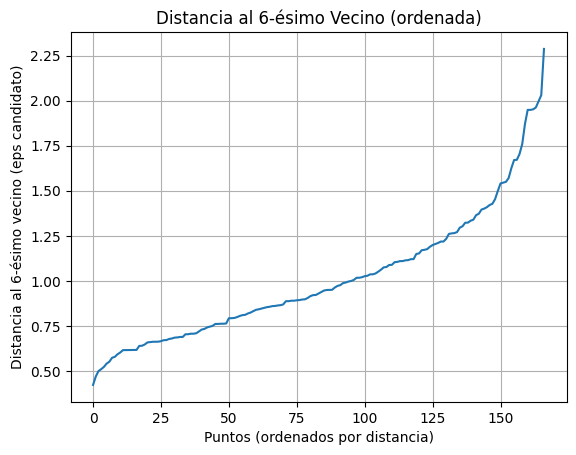

In [ ]:
# Estimación del hiperparámetro de eps
k_nn = min_samples

nearest_neighbors = NearestNeighbors(n_neighbors=k_nn)
neighbors_fit = nearest_neighbors.fit(df_pca)

distances, indices = neighbors_fit.kneighbors(df_pca)
distances = np.sort(distances[:, k_nn-1], axis=0) # Distancia al k-ésimo vecino

plt.plot(distances)
plt.title(f'Distancia al {k_nn}-ésimo Vecino (ordenada)')
plt.xlabel('Puntos (ordenados por distancia)')
plt.ylabel(f'Distancia al {k_nn}-ésimo vecino (eps candidato)')
plt.grid(True)
plt.show()

In [ ]:
# Selección del punto de curvatura máxima
kl = KneeLocator(
    range(len(distances)),
    distances,
    curve = 'convex',
    direction = 'increasing'
)

kl.elbow

np.int64(163)

In [ ]:
eps = distances[kl.elbow]
eps

np.float64(1.9618201536357585)

Dado que incluso con el valor estimado de eps el modelo sigue generando un único clúster (o no forma agrupamientos válidos), se opta por ajustar manualmente el valor de eps a un nivel ligeramente inferior, fijándolo en 1.5. Esta decisión permite que el modelo DBSCAN logre formar al menos dos agrupamientos válidos, evitando así el colapso en un solo clúster y habilitando la evaluación del modelo mediante métricas estandarizadas.

In [ ]:
# --- Modelo DBSCAN con PCA ---
dbscan_pca = DBSCAN(eps = 1.5, min_samples = min_samples)

# Ajustar el modelo
dbscan_pca.fit(df_pca)  # Usar el df_pca

DBSCAN(eps=1.5, min_samples=6)

In [ ]:
# --- Evaluación del modelo DBSCAN con PCA ---
print(" ### DBSCAN con PCA ###")
print('Silhouette Score: ', silhouette_score(df_pca, dbscan_pca.labels_))
print('Calinski harabasz score: ', calinski_harabasz_score(df_pca, dbscan_pca.labels_))

 ### DBSCAN con PCA ###
Silhouette Score:  0.1562697775940965
Calinski harabasz score:  7.166675288476453


In [ ]:
# Crear un DataFrame con los resultados de evaluación del modelo DBSCAN con PCA
result_pca_dbs = pd.DataFrame({
    'Silhouette Score': [silhouette_score(df_pca, dbscan_pca.labels_)],
    'Calinski Harabasz Score': [calinski_harabasz_score(df_pca, dbscan_pca.labels_)]
}, index=['PCA'])

result_pca_dbs

,Silhouette Score,Calinski Harabasz Score
PCA,0.15627,7.166675


In [ ]:
# Obtener las etiquetas de clúster asignadas por el modelo DBSCAN con PCA
labels = dbscan_pca.labels_

# Mostrar los valores únicos de etiquetas (clústeres detectados)
np.unique(labels)

array([-1,  0,  1])

A diferencia del modelo optimizado, el modelo DBSCAN aplicado sobre los datos transformados mediante PCA logra identificar dos clústeres válidos (etiquetas 0 y 1), además de un conjunto de observaciones clasificadas como ruido (etiqueta -1). Esto indica que la reducción de dimensionalidad contribuyó a una mejor diferenciación estructural entre las observaciones, permitiendo al algoritmo detectar agrupamientos con mayor claridad.

### <font color='FF7F50'> **6.3. Resultados**

Los resultados obtenidos para el modelo DBSCAN con reducción de dimensionalidad mediante PCA muestran un Silhouette Score de 0.156 y un Calinski-Harabasz Score de 7.17, lo cual indica un desempeño general pobre en términos de calidad de agrupamiento. Ambos valores son bajos, sugiriendo que los clústeres formados no presentan una estructura clara: ni están bien separados entre sí, ni muestran una cohesión interna sólida. Aunque el modelo logró identificar más de un clúster, a diferencia del modelo optimizado que colapsó en uno solo, los niveles de desempeño obtenidos reflejan que la segmentación no es suficientemente robusta como para extraer conclusiones confiables sobre patrones diferenciados entre los países.

In [ ]:
# Crear una copia del DataFrame original para conservar los nombres de los países
df_dbs_pca = df.copy()

# Agregar las etiquetas del modelo DBSCAN con PCA
df_dbs_pca['Cluster_DBS'] = dbscan_pca.labels_
df_dbs_pca

,Country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster_DBS
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,0
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,0
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,0
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,0


In [ ]:
# Cluster 0
print("Países en el cluster 0:")
print(df_dbs_pca[df_dbs_pca['Cluster_DBS'] == 0]['Country'].values)

# Cluster 1
print("\nPaíses en el cluster 1:")
print(df_dbs_pca[df_dbs_pca['Cluster_DBS'] == 1]['Country'].values)

Países en el cluster 0:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kyrgyz Republic' 'Lao' 'Latvia' 'Lebanon' 'Lesotho' 'Liber

Al observar la distribución de países en los clústeres generados por el modelo DBSCAN con PCA, se nota un desequilibrio considerable: el cluster 0 agrupa a una abrumadora mayoría de países, mientras que el cluster 1 contiene únicamente cinco países (Brunei, Kuwait, Omán, Qatar y Arabia Saudita), todos pertenecientes a economías con altos ingresos. La escasa diferenciación general y la desproporción en la asignación de países reflejan las limitaciones del modelo. Este comportamiento se alinea con las métricas de desempeño obtenidas, ya que tanto el Silhouette Score (0.156) como el Calinski-Harabasz Score (7.17) son muy bajos, lo que confirma que la estructura de clústeres es débil y no claramente definida.

In [ ]:
# Visualización 3D de Clústeres usando el modelo basado en PCA

# Copiar resultados PCA para graficar
df_pca_results_dbs = df_pca.copy()

# Obtener etiquetas del modelo
labels = dbscan_pca.labels_

# Convertir etiquetas a string y reemplazar -1 por "Ruido"
cluster_labels_str = pd.Series(labels).astype(str)
cluster_labels_str[cluster_labels_str == '-1'] = 'Ruido'

# Añadir la columna 'Cluster' al DataFrame para usar en plotly
df_pca_results_dbs['Cluster'] = cluster_labels_str.values

# Graficar con plotly express
fig = px.scatter_3d(data_frame=df_pca_results_dbs,
                    x='CP1',
                    y='CP2',
                    z='CP3',
                    color='Cluster',  # Aquí se usa la columna del DataFrame
                    title='Clusters en el Espacio de 3 Componentes Principales',
                    labels={'CP1': 'Componente Principal 1',
                            'CP2': 'Componente Principal 2',
                            'CP3': 'Componente Principal 3',
                            'color': 'Cluster'},
                    opacity=0.7,
                    size_max=10)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40),
                  scene=dict(
                      xaxis_title='CP1',
                      yaxis_title='CP2',
                      zaxis_title='CP3'
                  ))

fig.show()

Mediante el gráfico 3D generado en el espacio de las tres componentes principales, se confirma visualmente la formación de los clústeres identificados por el modelo, validando así la estructura y separación de grupos analizada previamente con las métricas y la asignación de países a cada clúster.

## <font color='8EC044'> **7. Análisis comparativo**

### <font color='FF7F50'> **7.1. Mejores modelos**

In [ ]:
# Crear un DataFrame con los mejores modelos y sus resultados
mejores_resultados = {
    'Modelo': ['K-Means (PCA)', 'Clustering Jerárquico (PCA)'],
    'Silhouette Score': [0.353334, 0.331480],
    'Calinski-Harabasz Score': [127.998924, 94.259633],
}

df_mejores_resultados = pd.DataFrame(mejores_resultados)

# Mostrar
df_mejores_resultados

,Modelo,Silhouette Score,Calinski-Harabasz Score
0,K-Means (PCA),0.353334,127.998924
1,Clustering Jerárquico (PCA),0.331480,94.259633


Con base en el análisis cuantitativo (métricas de validación) y cualitativo (composición de clústeres y visualización tridimensional), el modelo de K-Means con PCA se perfila como el más adecuado para representar la estructura latente de los datos. A continuación, se detallan las razones clave:

Desde el punto de vista cuantitativo, K-Means con PCA obtuvo un Silhouette Score de 0.353 y un Calinski-Harabasz Score de 127.99, superando en ambos aspectos al modelo de clustering jerárquico, que presentó un Silhouette Score de 0.331 y un Calinski-Harabasz Score de 94.26. Estos indicadores sugieren que K-Means logra una mejor cohesión interna dentro de los clústeres y una mayor separación entre ellos, lo que se traduce en una segmentación más definida y robusta.

En cuanto al análisis cualitativo, el modelo K-Means fue capaz de distinguir claramente dos grupos de países con características bien diferenciadas en términos de desarrollo humano, económico y sanitario. El cluster 0 agrupa a naciones con alto desarrollo socioeconómico como Alemania, Estados Unidos, Japón y Australia, mientras que el cluster 1 incluye principalmente países con indicadores más rezagados como Afganistán, Nigeria o Bangladesh. Esta división resulta coherente con patrones reales de desarrollo global, lo cual respalda la validez del modelo. Además, los clústeres presentan un buen equilibrio en términos de tamaño y una disposición compacta, lo que está alineado con las suposiciones teóricas del algoritmo K-Means.

Por otro lado, aunque el modelo de clustering jerárquico también identifica dos grandes grupos, se observan ciertos aspectos menos favorables. En este caso, existe un desbalance importante en el tamaño de los clústeres, siendo uno de ellos considerablemente más amplio y más disperso internamente. Además, algunas asignaciones resultan menos intuitivas o controvertidas, como el agrupamiento de países como China en el mismo clúster que los menos desarrollados. Esto podría indicar que el modelo jerárquico es más sensible a diferencias relativas menores y menos efectivo en captar divisiones estructurales significativas.

Finalmente, la visualización 3D del espacio reducido por PCA refuerza la superioridad de K-Means, ya que muestra clústeres bien definidos, separados y compactos, mientras que en el modelo jerárquico se detecta mayor solapamiento y dispersión.

En resumen, al considerar tanto los indicadores de calidad como la coherencia conceptual de los resultados, se concluye que el modelo K-Means con PCA es el más adecuado para este análisis de agrupamiento. Ofrece una segmentación clara, balanceada y útil para interpretar diferencias socioeconómicas entre países.

### <font color='FF7F50'> **7.2. Conclusiones y recomendaciones**

A lo largo de este caso de estudio se logró segmentar a los países en grupos homogéneos en función de variables socioeconómicas y de salud mediante técnicas de aprendizaje no supervisado, específicamente con modelos de clustering aplicados sobre un espacio reducido por PCA. Entre los modelos evaluados, el algoritmo K-Means combinado con PCA resultó ser el más efectivo, tanto por sus métricas de evaluación como por la coherencia interpretativa de los clústeres obtenidos. La agrupación permitió distinguir claramente entre países con altos y bajos niveles de desarrollo, lo que demuestra el poder de estas herramientas para revelar patrones estructurales en datos multidimensionales. Sería interesante poder incorporar nuevas variables, como indicadores educativos o ambientales, que podrían enriquecer la segmentación obtenida y ofrecer una visión más integral del desarrollo de los países. También sería útil explorar modelos más avanzados, como HDBSCAN o t-SNE, para detectar subgrupos más sutiles o patrones no lineales en los datos.

